# IS525E – Data Science for Business  
## Supply Chain Analytics  
### Inventory Optimization Using Predictive Analytics

**Dataset:** `apple_global_sales_dataset.csv`
   
**Team members:** YU-HSIN LIU, Fernanda AGUIRRE OROPEZA, René Alfonso SORIANO RUIZ

### Project overview
This project uses Apple global sales data to answer a practical supply chain question: **how much stock should the company prepare next month for the most important products inside each category?**

To make the analysis more useful from a business perspective, we do not stay with one global ranking. Instead, we keep the **top 3 products within each category** based on total units sold. That gives a more balanced view across iPhone, Mac, iPad, Apple Watch, AirPods, and Accessories.

The project keeps a monthly planning perspective. It studies recent sales behavior, compares three predictive models, selects the strongest option, and then translates the forecast into operational metrics such as safety stock, reorder point, target stock level, and recommended order quantity.

The project outlines:
 1. Define the problem
 2. Clean the data
 3. Explore demand patterns
 4. Build and evaluate the models
 5. Create the inventory plan

## 1. PROBLEM STATEMENT AND OBJECTIVE

Inventory decisions matter because both extremes are costly. When stock is too low, the company risks losing sales and affecting the customer experience. When stock is too high, working capital remains tied up in products that are not moving fast enough.

The central business question is straightforward:

**How can historical sales data help improve inventory planning for the most important products inside each category?**

The objective is to build a forecasting workflow that estimates next-month demand and turns that estimate into a practical inventory plan. In other words, the purpose is not only to describe what happened in the past. The purpose is to support a better operational decision for the next planning cycle.

## 2. JUSTIFICATION

A supervised regression approach makes sense because the decision depends on estimating future demand. Monthly sales usually contain signals from recent history, and those signals can be converted into more informed replenishment decisions.

The notebook compares three models with different strengths. **Linear Regression** works as a clear and interpretable baseline. **Random Forest** helps when the relationship is less linear. **Gradient Boosting** provides another strong benchmark when interactions matter more.

The models are evaluated with **MAE, RMSE, MAPE, and R²**. Together, these metrics help answer a practical question: which model is accurate enough to support inventory planning in a realistic way?

This project is licensed under the MIT License.


In [1]:
# ==========================================================
# STEP 1 - IMPORT THE LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Optional display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Apple-inspired visual palette
APPLE_BLACK = "#1D1D1F"
APPLE_BLUE = "#0071E3"
APPLE_SILVER = "#D2D2D7"
APPLE_LIGHT = "#F5F5F7"
APPLE_GRAY = "#86868B"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = APPLE_SILVER
plt.rcParams["grid.color"] = APPLE_SILVER
plt.rcParams["axes.titlecolor"] = APPLE_BLACK
plt.rcParams["axes.labelcolor"] = APPLE_BLACK
plt.rcParams["xtick.color"] = APPLE_BLACK
plt.rcParams["ytick.color"] = APPLE_BLACK

Before doing any analysis, the we prepare the working environment. This includes the main data tools, the predictive models, the evaluation metrics, and a clean visual style.

The color palette is intentionally simple and close to Apple’s visual identity. That choice helps the charts look more consistent with the case while staying easy to read in a business presentation.

In [2]:
# ==========================================================
# STEP 2 - UPLOAD THE EXCEL FILE
# ==========================================================

uploaded = files.upload()

Saving apple_global_sales_dataset.csv to apple_global_sales_dataset.csv


In [3]:
# ==========================================================
# STEP 2B - READ THE EXCEL FILE
# ==========================================================

df = pd.read_csv("apple_global_sales_dataset.csv")
df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")

display(df.head())

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,storage,color,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,NaN,Starlight,159.270,7,1,148.120,148.120,ARS,907.000,"134,344.840",Third-Party Retailer,Cash,Government,45–54,NaN,4.100,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,NaN,Black,29.990,15,5,25.490,127.450,ARS,907.000,"115,597.150",Authorized Reseller,Debit Card,Business,45–54,NaN,4.800,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,NaN,Titanium,293.920,0,4,293.920,"1,175.680",ARS,907.000,"1,066,341.760",Corporate / B2B,Credit Card,Individual,18–24,NaN,4.300,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,1 TB SSD,Starlight,"1,932.770",0,2,"1,932.770","3,865.540",ARS,907.000,"3,506,044.780",Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,NaN,Midnight,755.440,5,3,717.670,"2,153.010",ARS,907.000,"1,952,780.070",Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


## 3. INITIAL DATA EXPLORATION

At this stage, the goal is simply to confirm that the dataset is usable for the business question. A quick inspection helps verify the structure, identify possible missing values, and highlight the fields that matter most for inventory planning.

For this project, the key variable is **units_sold**, because it represents demand. The date field is also essential, since the analysis will later be organized at the monthly level.

In [4]:
# ==========================================================
# STEP 3 - INITIAL DATA EXPLORATION
# ==========================================================

print("Shape of the dataset:", df.shape)
print("\nColumn names:")
print(df.columns)
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())
print("\nStatistical summary:")
display(df.describe(include="all"))

Shape of the dataset: (11500, 27)

Column names:
Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'storage', 'color',
       'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
       'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency',
       'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'previous_device_os', 'customer_rating',
       'return_status'],
      dtype='object')

Data types:
sale_id                           object
sale_date                 datetime64[ns]
year                               int64
quarter                           object
month                             object
country                           object
region                            object
city                              object
product_name                      object
category                          object
storage                           object
color   

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,storage,color,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,NaN,Starlight,159.270,7,1,148.120,148.120,ARS,907.000,"134,344.840",Third-Party Retailer,Cash,Government,45–54,NaN,4.100,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,NaN,Black,29.990,15,5,25.490,127.450,ARS,907.000,"115,597.150",Authorized Reseller,Debit Card,Business,45–54,NaN,4.800,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,NaN,Titanium,293.920,0,4,293.920,"1,175.680",ARS,907.000,"1,066,341.760",Corporate / B2B,Credit Card,Individual,18–24,NaN,4.300,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,1 TB SSD,Starlight,"1,932.770",0,2,"1,932.770","3,865.540",ARS,907.000,"3,506,044.780",Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,NaN,Midnight,755.440,5,3,717.670,"2,153.010",ARS,907.000,"1,952,780.070",Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept



Statistical summary:


,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,storage,color,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
count,11500,11500,"11,500.000",11500,11500,11500,11500,11500,11500,11500,6696,11500,"11,500.000","11,500.000","11,500.000","11,500.000","11,500.000",11500,"11,500.000","11,500.000",11500,11500,11500,11500,3444,"8,140.000",11500
unique,11500,NaN,NaN,4,12,47,8,514,43,6,10,20,NaN,NaN,NaN,NaN,NaN,38,NaN,NaN,6,7,4,5,6,NaN,3
top,APPL-00011500,NaN,NaN,Q4,March,Japan,Europe,Singapore,Apple Watch SE (2nd Gen),iPhone,64 GB,Silver,NaN,NaN,NaN,NaN,NaN,EUR,NaN,NaN,Online (Apple.com),Credit Card,Government,25–34,Android,NaN,Kept
freq,1,NaN,NaN,2922,1047,274,3898,237,312,3444,944,1690,NaN,NaN,NaN,NaN,NaN,2433,NaN,NaN,1940,1683,2892,2347,595,NaN,10143
mean,NaN,2023-06-30 22:03:32.869564928,"2,022.997",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,807.851,3.842,2.023,777.365,"1,568.319",NaN,"1,029.407","1,464,369.410",NaN,NaN,NaN,NaN,NaN,4.001,NaN
min,NaN,2022-01-01 00:00:00,"2,022.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.690,0.000,1.000,22.730,23.000,NaN,0.790,21.300,NaN,NaN,NaN,NaN,NaN,3.000,NaN
25%,NaN,2022-09-29 00:00:00,"2,022.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.148,0.000,1.000,178.297,305.740,NaN,0.920,"1,041.693",NaN,NaN,NaN,NaN,NaN,3.500,NaN
50%,NaN,2023-06-27 00:00:00,"2,023.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,593.905,2.000,1.000,573.420,833.040,NaN,7.240,"6,164.160",NaN,NaN,NaN,NaN,NaN,4.000,NaN
75%,NaN,2024-04-02 00:00:00,"2,024.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,958.388,7.000,3.000,928.567,"1,748.360",NaN,91.500,"74,716.530",NaN,NaN,NaN,NaN,NaN,4.500,NaN
max,NaN,2024-12-31 00:00:00,"2,024.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"7,551.010",15.000,8.000,"7,551.010","59,529.520",NaN,"24,500.000","507,517,500.000",NaN,NaN,NaN,NaN,NaN,5.000,NaN


## 4. CHECK MISSING VALUES AND DUPLICATES

We convert the date field, keep the rows that are valid for this analysis, and remove duplicates if they exist.

Some variables contain missing values, but not all of them are critical for this supply chain problem. Since the objective is demand forecasting and inventory planning, we keep the preparation focused on the variables that directly support that decision.

In [5]:
# ==========================================================
# STEP 4 - CHECK MISSING VALUES AND DUPLICATES
# ==========================================================
print("Missing values per column:")
display(df.isnull().sum().loc[lambda x: x > 0].to_frame(name="Missing_Values").sort_values("Missing_Values", ascending=False))

print("\nNumber of duplicated rows:", df.duplicated().sum())

Missing values per column:


,Missing_Values
previous_device_os,8056
storage,4804
customer_rating,3360



Number of duplicated rows: 0


## 5. CLEAN THE DATA

Since we found missing values only on the columns that have categorical information that is not relevant to the study, we only removed duplicated rows and droped the unused columns.

In [6]:
# ==========================================================
# STEP 5 - CLEAN THE DATA
# ==========================================================

# Drop the categorical columns with missing values
df = df.drop(columns=df.columns[df.isnull().sum() > 0])

# Remove duplicated rows if any
df = df.drop_duplicates()
print("Missing values after cleaning:")
display(df.isnull().sum().to_frame(name="Missing_Values_after_cleaning"))

print("\nNumber of duplicated rows after cleaning:",
df.duplicated().sum())


Missing values after cleaning:


,Missing_Values_after_cleaning
sale_id,0
sale_date,0
year,0
quarter,0
month,0
country,0
region,0
city,0
product_name,0
category,0



Number of duplicated rows after cleaning: 0


## 6. BASIC DESCRIPTIVE ANALYSIS

,units_sold,discounted_price_usd,unit_price_usd,revenue_usd
count,"11,500.000","11,500.000","11,500.000","11,500.000"
mean,2.023,777.365,807.851,"1,568.319"
std,1.444,"1,072.915","1,112.438","2,839.760"
min,1.000,22.730,26.690,23.000
25%,1.000,178.297,180.148,305.740
50%,1.000,573.420,593.905,833.040
75%,3.000,928.567,958.388,"1,748.360"
max,8.000,"7,551.010","7,551.010","59,529.520"


,category,units_sold
0,iPhone,6908
1,Accessories,5298
2,Mac,3789
3,iPad,2824
4,Apple Watch,2305
5,AirPods,2146


,product_name,units_sold
0,Apple Watch SE (2nd Gen),664
1,iPad Mini (6th Gen),647
2,MacBook Pro 16-inch (M3 Pro),620
3,iPhone 14 Pro,608
4,AirPods Pro (2nd Gen),603
5,MacBook Air 13-inch (M2),598
6,iPhone 13 Mini,590
7,MagSafe Charger,579
8,iPhone 13 Pro Max,577
9,iPad (10th Generation),576


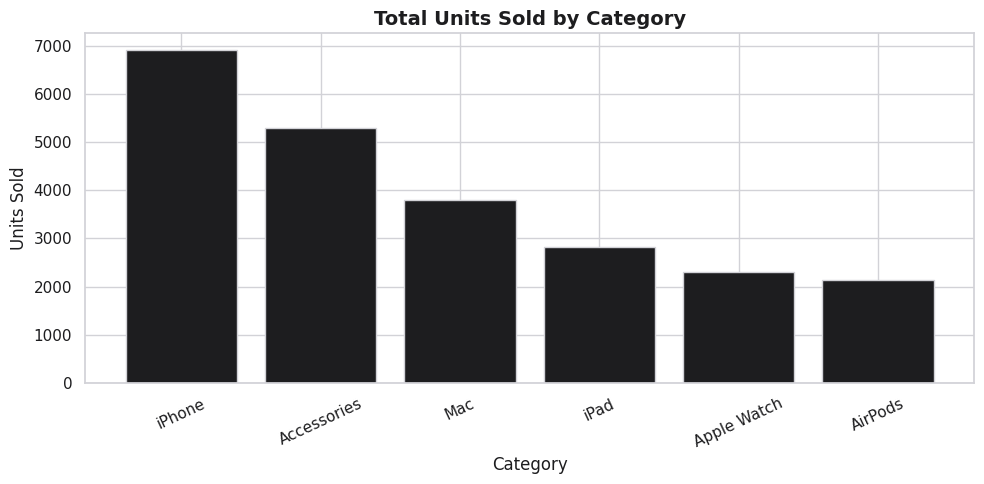

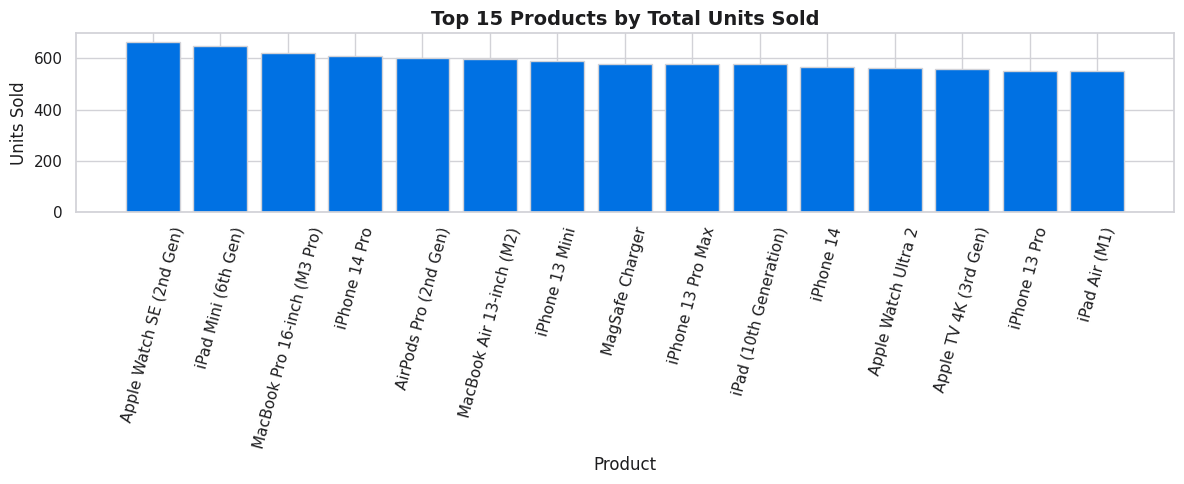

In [7]:
# ==========================================================
# STEP 6 - BASIC DESCRIPTIVE ANALYSIS
# ==========================================================

summary_stats = df[["units_sold", "discounted_price_usd", "unit_price_usd", "revenue_usd"]].describe()
display(summary_stats)

top_categories = (
    df.groupby("category")["units_sold"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

top_products = (
    df.groupby("product_name")["units_sold"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
      .reset_index()
)

display(top_categories)
display(top_products)

plt.figure(figsize=(10, 5))
plt.bar(top_categories["category"], top_categories["units_sold"], color=APPLE_BLACK, edgecolor=APPLE_SILVER)
plt.title("Total Units Sold by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(top_products["product_name"], top_products["units_sold"], color=APPLE_BLUE, edgecolor=APPLE_SILVER)
plt.title("Top 15 Products by Total Units Sold", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

At this point, the goal is to identify where inventory decisions matter most. The category view shows where the largest share of demand is concentrated, while the product view gives a first signal of which items are strongest overall.

This makes the next selection rule easier to justify. Instead of keeping only one overall ranking, the project retains the **top 3 products within each category** so the analysis stays broad, balanced, and relevant across the portfolio.

These charts show that demand is not distributed evenly across the portfolio. That matters because inventory planning should not treat all products in the same way.

By keeping the **top 3 products within each category**, the project avoids overconcentrating the analysis in a single product family and creates a more useful business view of where replenishment priorities may emerge.

## 7. SELECT THE TOP 3 PRODUCTS IN EACH CATEGORY

Instead of working with individual transactions, we reorganize the information at the monthly level. This is more useful because procurement and replenishment are usually reviewed by period, not by single sale.

At the same time, we keep the color signal in the data by creating **color dummies before monthly aggregation**. That way, the monthly dataset stays simple enough for modeling while still preserving information that can later support product-color recommendations in the inventory plan.

For product selection, we choose the **top 3 products inside each category** based on total units sold.

When the monthly dataset is built, color is encoded before aggregation. This preserves the variation associated with color without turning the full analytical table into a much more fragmented time series. That is a practical middle ground due to the model learns from monthly demand patterns, and the final recommendation can still reconnect the analysis with product-color decisions.

In [8]:
# ==========================================================
# STEP 7 - SELECT THE TOP 3 PRODUCTS IN EACH CATEGORY
# ==========================================================

top_3_by_category = (
    df.groupby(["category", "product_name"])["units_sold"]
      .sum()
      .reset_index()
      .sort_values(["category", "units_sold"], ascending=[True, False])
      .groupby("category")
      .head(3)
      .reset_index(drop=True)
)

top_df = df.merge(
    top_3_by_category[["category", "product_name"]],
    on=["category", "product_name"],
    how="inner"
).copy()

print("Selected top 3 products by category:")
display(top_3_by_category)

print("\nFiltered dataset shape:", top_df.shape)

Selected top 3 products by category:


,category,product_name,units_sold
0,Accessories,MagSafe Charger,579
1,Accessories,Apple TV 4K (3rd Gen),559
2,Accessories,Magic Mouse,548
3,AirPods,AirPods Pro (2nd Gen),603
4,AirPods,AirPods Max,547
5,AirPods,AirPods (2nd Gen),542
6,Apple Watch,Apple Watch SE (2nd Gen),664
7,Apple Watch,Apple Watch Ultra 2,564
8,Apple Watch,Apple Watch Series 9,549
9,Mac,MacBook Pro 16-inch (M3 Pro),620



Filtered dataset shape: (5001, 24)


## 8. ENCODE THE VARIABLE 'color'

We were assuming that Color might affect how much a product sells. Encoding the color variable enabled the model to incorporate product-level attributes into demand forecasting, allowing for a more detailed and realistic representation of customer preferences.

In [9]:
# ==========================================================
# STEP 8 - ENCODE OBJECT VARIABLES (EXCEPT SELECTED ONES)
# ==========================================================

# Columns we want to keep without encoding
exclude_cols = [
    "sale_id",
    "quarter",
    "month",
    "product_name",
    "customer_segment",
    "customer_age_group"
]

# Detect all object columns
object_cols = top_df.select_dtypes(include="object").columns.tolist()

# Keep only object columns that should be encoded
cols_to_encode = [col for col in object_cols if col not in exclude_cols]

# Create dummies as numeric 0/1
top_df_encoded = pd.get_dummies(
    top_df,
    columns=cols_to_encode,
    drop_first=False,
    dtype=int
)

color_dummy_cols = [ col for col in top_df_encoded.columns if col.startswith("color_") ]

display(top_df_encoded.head())

,sale_id,sale_date,year,quarter,month,product_name,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_segment,customer_age_group,country_Argentina,country_Australia,country_Austria,country_Bangladesh,country_Belgium,country_Brazil,country_Canada,country_Chile,country_China,country_Colombia,country_Denmark,country_Egypt,country_Finland,country_France,country_Germany,country_Hong Kong,country_India,country_Indonesia,country_Ireland,country_Italy,country_Japan,country_Kenya,country_Malaysia,country_Mexico,country_Netherlands,country_New Zealand,country_Nigeria,country_Norway,country_Pakistan,country_Philippines,country_Poland,country_Portugal,country_Russia,country_Saudi Arabia,country_Singapore,country_South Africa,country_South Korea,country_Spain,country_Sweden,country_Switzerland,country_Taiwan,country_Thailand,country_Turkey,country_UAE,country_United Kingdom,country_United States,country_Vietnam,region_Africa,region_Asia,region_Europe,region_Europe/Asia,region_Middle East,region_North America,region_Oceania,region_South America,city_Aalborg,city_Aalst,city_Aarhus,city_Abu Dhabi,city_Abuja,city_Adana,city_Adelaide,city_Agra,city_Ahmedabad,city_Ajman,city_Al Ain,city_Alexandria,city_Alicante,city_Almada,city_Almere,city_Amadora,city_Amsterdam,city_Ankara,city_Antalya,city_Antipolo,city_Antofagasta,city_Antwerp,city_Arica,city_Asyut,city_Auckland,city_Austin,city_Aveiro,city_Baltimore,city_Bandung,city_Bangalore,city_Bangkok,city_Barcelona,city_Bari,city_Barranquilla,city_Basel,city_Beijing,city_Bekasi,city_Belo Horizonte,city_Belém,city_Benin City,city_Bergen,city_Berlin,city_Bern,city_Bhopal,city_Biel,city_Bien Hoa,city_Bilbao,city_Birmingham,city_Bloemfontein,city_Bochum,city_Bogotá,city_Bologna,city_Bordeaux,city_Boston,city_Braga,city_Brasília,city_Bray,city_Breda,city_Bremen,city_Brisbane,city_Bristol,city_Bruges,city_Brussels,city_Bucaramanga,city_Buenos Aires,city_Buraidah,city_Bursa,city_Busan,city_Bydgoszcz,city_Cagayan de Oro,city_Cairo,city_Calgary,city_Cali,city_Caloocan,city_Campinas,city_Can Tho,city_Canberra,city_Cape Town,city_Cardiff,city_Cartagena,city_Catania,city_Cebu City,city_Central,city_Changhua,city_Changsha,city_Changwon,city_Charlotte,city_Chelyabinsk,city_Chengdu,city_Chennai,city_Chiang Mai,city_Chiayi,city_Chicago,city_Chittagong,city_Chongqing,city_Christchurch,city_Ciudad Juárez,city_Coimbra,city_Cologne,city_Columbus,city_Comilla,city_Concepción,city_Copenhagen,city_Cork,city_Curitiba,city_Córdoba,city_Cúcuta,city_Da Nang,city_Daegu,city_Daejeon,city_Dallas,city_Dammam,city_Darwin,city_Davao,city_Delhi,city_Denver,city_Depok,city_Dhaka,city_Dijon,city_Dongguan,city_Dornbirn,city_Dortmund,city_Drammen,city_Dresden,city_Drogheda,city_Dubai,city_Dublin,city_Dundalk,city_Dunedin,city_Durban,city_Düsseldorf,city_East London,city_Edinburgh,city_Edmonton,city_Eindhoven,city_Eldoret,city_Ennis,city_Enugu,city_Esbjerg,city_Espoo,city_Faisalabad,city_Faridabad,city_Florence,city_Fort Worth,city_Fortaleza,city_Foshan,city_Frankfurt,city_Fredrikstad,city_Fujairah,city_Fukuoka,city_Funchal,city_Galway,city_Gaziantep,city_Gdansk,city_Geneva,city_Genoa,city_George Town,city_Ghent,city_Gijón,city_Giza,city_Glasgow,city_Goiânia,city_Gold Coast,city_Gothenburg,city_Goyang,city_Graz,city_Grenoble,city_Groningen,city_Guadalajara,city_Guangzhou,city_Guarulhos,city_Guimarães,city_Gujranwala,city_Gwangju,city_Haiphong,city_Halifax,city_Hamburg,city_Hamilton,city_Hangzhou,city_Hanoi,city_Hanover,city_Harbin,city_Hat Yai,city_Helsingborg,city_Helsinki,city_Hiroshima,city_Ho Chi Minh City,city_Hobart,city_Horsens,city_Houston,city_Hsinchu,city_Hue,city_Hyderabad,city_Ibadan,city_Ibagué,city_Ilorin,city_Incheon,city_Indore,city_Innsbruck,city_Ipoh,city_Islamabad,city_Istanbul,city_Izmir,city_Jacksonville,city_Jaipur,city_Jakarta,city_Jeddah,city_Johannesburg,city_Johor Bahru,city_Jubail,city_Jyväskylä,city_Jönköping,city_Kaduna,city_Kano,city_Kanpur,cit

## 9. BUILD A MONTHLY PRODUCT-COLOR LEVEL DATASET

The dataset was structured at a product-color-month level to capture demand patterns over time at a granular level. By aggregating the data at a monthly product-color level, the analysis captures both temporal dynamics and product variation, enabling more accurate demand forecasting and more targeted inventory strategies.

In [10]:
# ==========================================================
# STEP 9  - BUILD A MONTHLY PRODUCT-COLOR-LEVEL DATASET
# ==========================================================
monthly = (
    top_df_encoded.assign(
        month_start=top_df_encoded["sale_date"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby(["product_name", "month_start"], as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        avg_discount_pct=("discount_pct", "mean"),
        avg_unit_price=("unit_price_usd", "mean"),
        revenue_usd=("revenue_usd", "sum"),
        transactions=("sale_id", "count"),
        **{col: (col, "sum") for col in color_dummy_cols}
    )
)

# Complete monthly grid for each category-product combination
all_months = pd.date_range(
    monthly["month_start"].min(),
    monthly["month_start"].max(),
    freq="MS"
)

combo_df = monthly[["product_name"]].drop_duplicates().copy()
combo_df["key"] = 1
months_df = pd.DataFrame({"month_start": all_months, "key": 1})

full_grid = combo_df.merge(months_df, on="key").drop(columns="key")

monthly = full_grid.merge(
    monthly,
    on=["product_name", "month_start"],
    how="left"
)

# Fill missing values created by the monthly grid
avg_price_by_product = (
    top_df.groupby("product_name")["unit_price_usd"]
          .mean()
          .to_dict()
)

monthly["avg_unit_price"] = monthly["avg_unit_price"].fillna(
    monthly["product_name"].map(avg_price_by_product)
)
monthly["avg_discount_pct"] = monthly["avg_discount_pct"].fillna(0)
monthly["revenue_usd"] = monthly["revenue_usd"].fillna(0)
monthly["transactions"] = monthly["transactions"].fillna(0)
monthly["units_sold"] = monthly["units_sold"].fillna(0)

for col in color_dummy_cols:
    monthly[col] = monthly[col].fillna(0)

monthly["transactions"] = monthly["transactions"].astype(int)
monthly["units_sold"] = monthly["units_sold"].astype(int)

monthly = monthly.sort_values(
    ["product_name", "month_start"]
).reset_index(drop=True)

print("Monthly dataset shape:", monthly.shape)
display(monthly.head(20))

Monthly dataset shape: (648, 27)


,product_name,month_start,units_sold,avg_discount_pct,avg_unit_price,revenue_usd,transactions,color_Black,color_Black Titanium,color_Blue,color_Blue Titanium,color_Deep Purple,color_Gold,color_Green,color_Midnight,color_Natural,color_Natural Titanium,color_Product Red,color_Purple,color_Silver,color_Sky,color_Space Gray,color_Starlight,color_Titanium,color_White,color_White Titanium,color_Yellow
0,AirPods (2nd Gen),2022-01-01,17,3.667,127.919,"2,116.640",12,0,0,0,0,0,0,0,5,0,0,0,0,0,1,0,3,0,3,0,0
1,AirPods (2nd Gen),2022-02-01,16,3.667,127.353,"1,980.500",9,0,0,0,0,0,0,0,3,0,0,0,0,0,2,0,2,0,2,0,0
2,AirPods (2nd Gen),2022-03-01,30,3.500,127.177,"3,704.160",12,0,0,0,0,0,0,0,3,0,0,0,0,0,3,0,3,0,3,0,0
3,AirPods (2nd Gen),2022-04-01,7,0.667,130.167,903.720,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0
4,AirPods (2nd Gen),2022-05-01,19,5.000,128.657,"2,363.640",6,0,0,0,0,0,0,0,2,0,0,0,0,0,1,0,0,0,3,0,0
5,AirPods (2nd Gen),2022-06-01,16,6.500,127.245,"1,902.370",10,0,0,0,0,0,0,0,2,0,0,0,0,0,4,0,1,0,3,0,0
6,AirPods (2nd Gen),2022-07-01,12,2.000,131.322,"1,526.890",8,0,0,0,0,0,0,0,3,0,0,0,0,0,1,0,2,0,2,0,0
7,AirPods (2nd Gen),2022-08-01,9,3.750,131.500,"1,161.200",4,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0
8,AirPods (2nd Gen),2022-09-01,18,1.000,128.600,"2,329.880",8,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,3,0,3,0,0
9,AirPods (2nd Gen),2022-10-01,18,3.500,126.699,"2,225.760",8,0,0,0,0,0,0,0,2,0,0,0,0,0,1,0,2,0,3,0,0


## 10. VISUALIZE MONTHLY DEMAND FOR THE SELECTED PRODUCTS

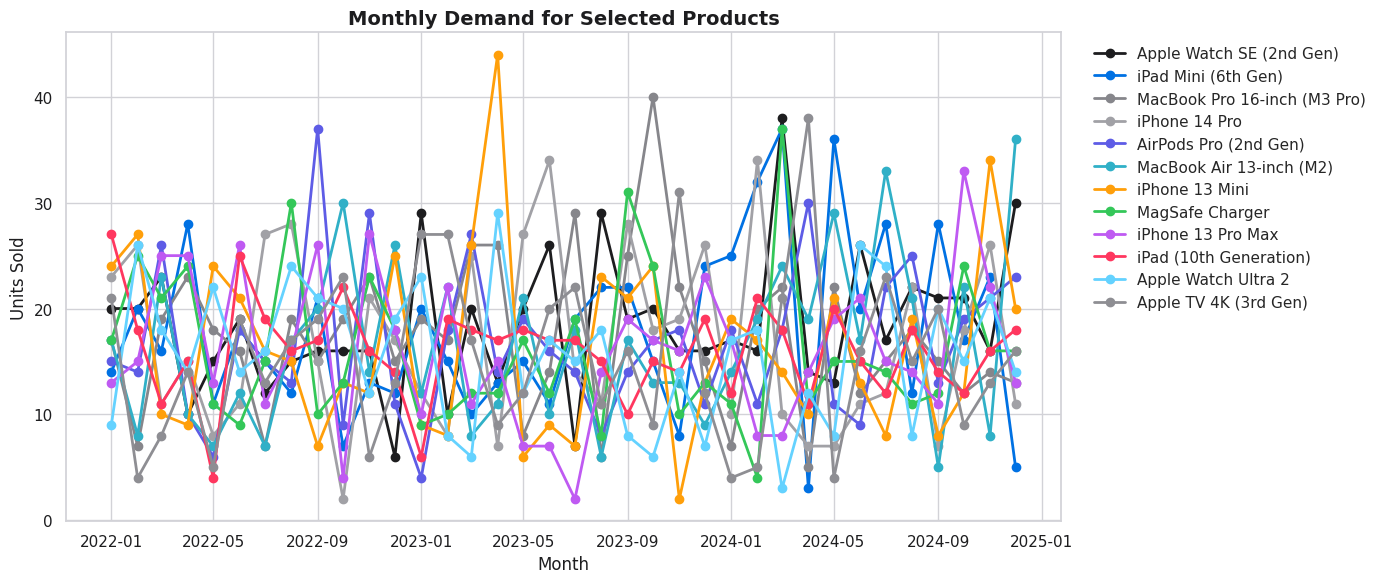

In [11]:

# ==========================================================
# STEP 10 - VISUALIZE MONTHLY DEMAND FOR THE SELECTED PRODUCTS
# ==========================================================

product_totals = (
    monthly.groupby("product_name")["units_sold"]
           .sum()
           .sort_values(ascending=False)
           .head(12)
           .index
           .tolist()
)

apple_line_colors = [
    APPLE_BLACK, APPLE_BLUE, APPLE_GRAY, "#A1A1A6", "#5E5CE6",
    "#30B0C7", "#FF9F0A", "#34C759", "#BF5AF2", "#FF375F",
    "#64D2FF", "#8E8E93"
]

plt.figure(figsize=(14, 6))
for idx, product in enumerate(product_totals):
    temp = (
        monthly[monthly["product_name"] == product]
        .groupby("month_start", as_index=False)["units_sold"]
        .sum()
    )
    plt.plot(
        temp["month_start"],
        temp["units_sold"],
        marker="o",
        linewidth=2,
        color=apple_line_colors[idx % len(apple_line_colors)],
        label=product
    )

plt.title("Monthly Demand for Selected Products", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

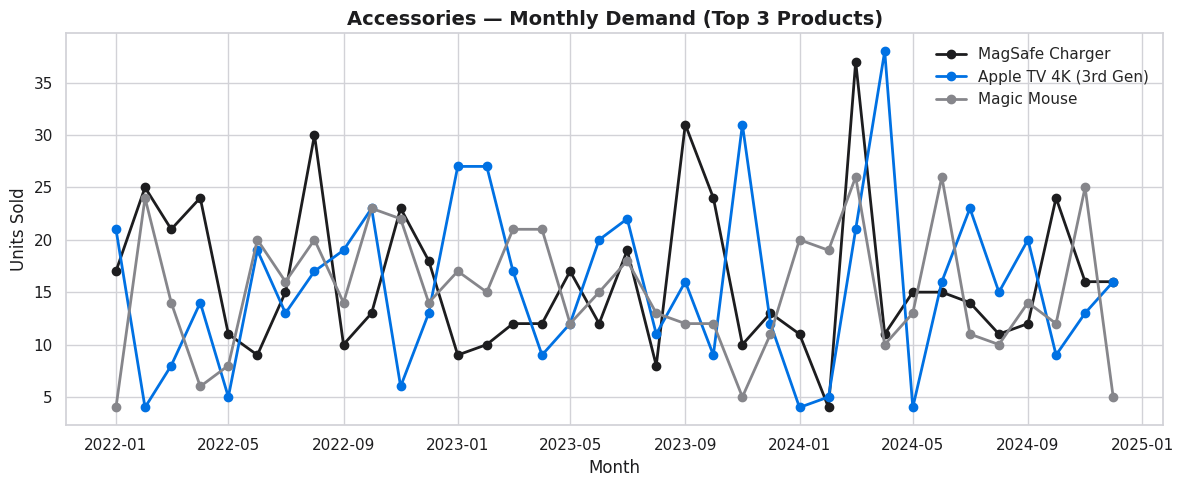

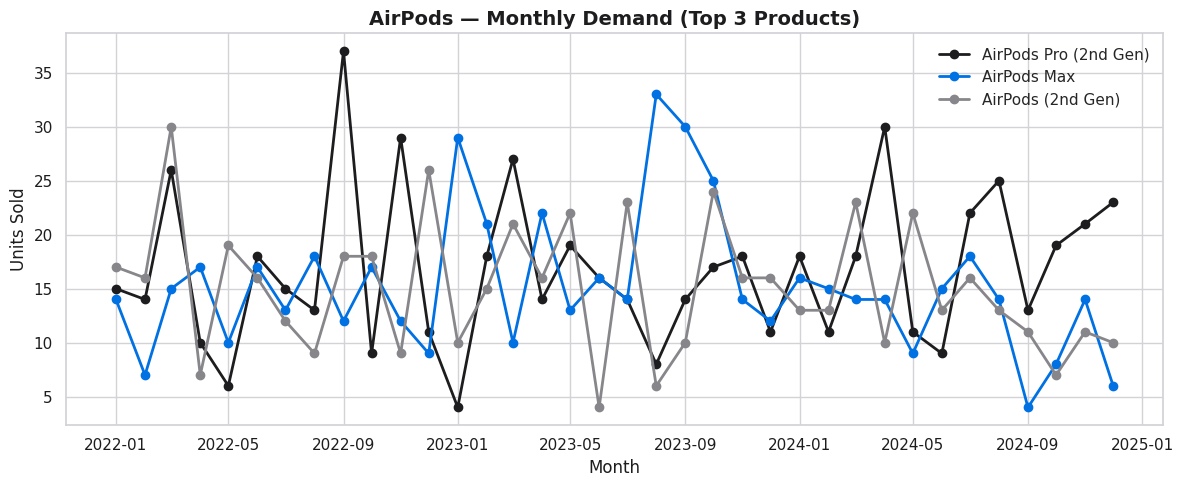

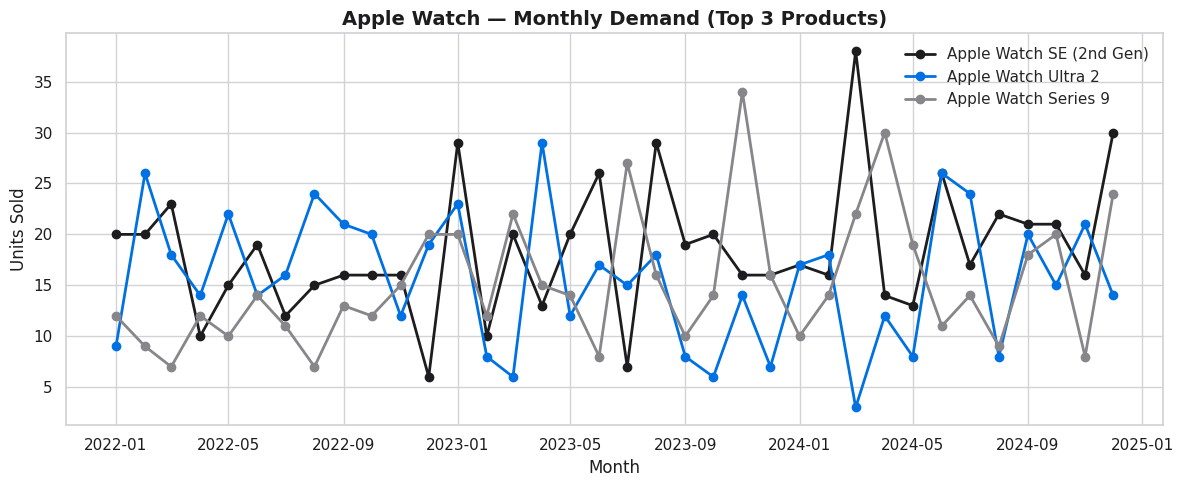

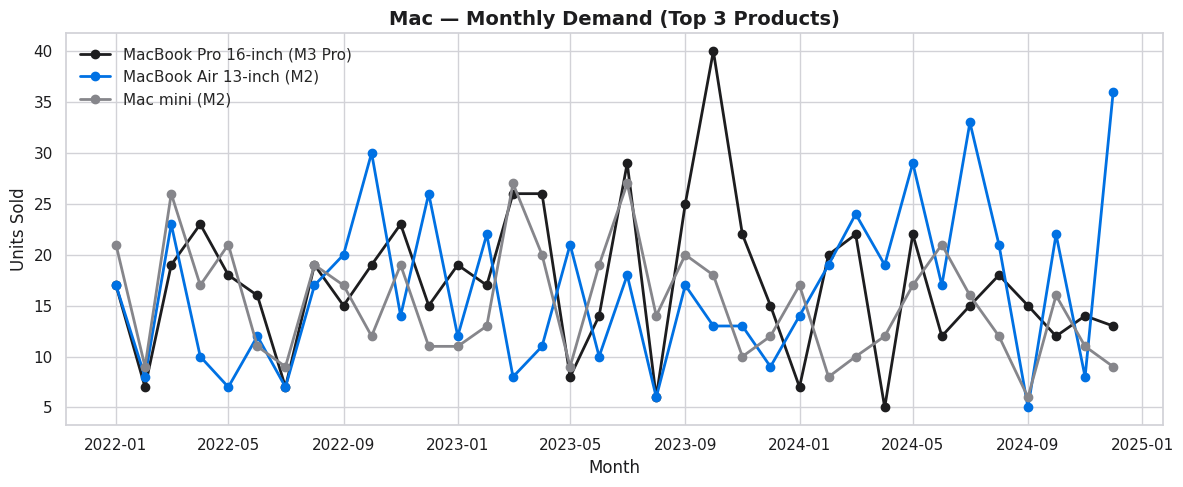

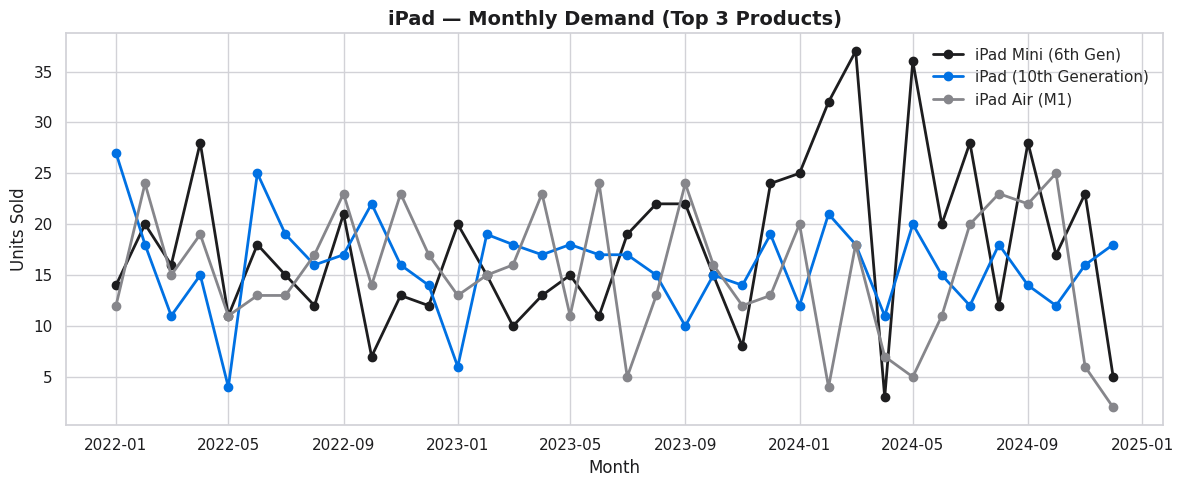

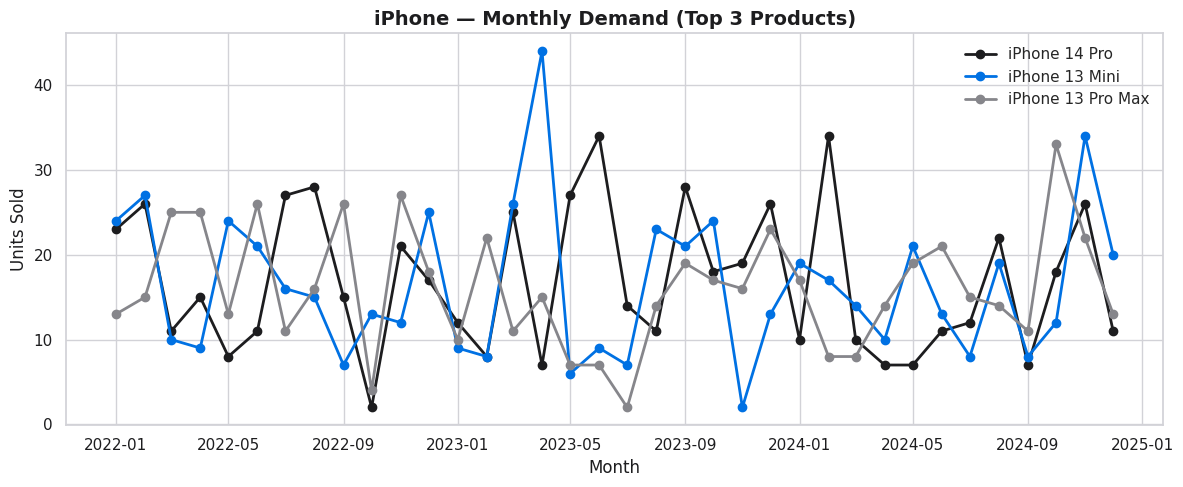

In [27]:
# ==========================================================
# STEP 10B - PLOT PER CATEGORY (TOP 3 PRODUCTS)
# ==========================================================

categories = top_3_by_category["category"].unique()

apple_line_colors = [APPLE_BLACK, APPLE_BLUE, APPLE_GRAY]

for category in categories:

    products = top_3_by_category[
        top_3_by_category["category"] == category
    ]["product_name"].tolist()

    plt.figure(figsize=(12, 5))

    for idx, product in enumerate(products):

        temp = (
            monthly[monthly["product_name"] == product]
            .groupby("month_start", as_index=False)["units_sold"]
            .sum()
            .sort_values("month_start")
        )

        plt.plot(
            temp["month_start"],
            temp["units_sold"],
            marker="o",
            linewidth=2,
            color=apple_line_colors[idx % len(apple_line_colors)],
            label=product
        )

    plt.title(f"{category} — Monthly Demand (Top 3 Products)",
              fontsize=14, fontweight="bold")

    plt.xlabel("Month")
    plt.ylabel("Units Sold")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

The monthly demand lines show clearly that demand is not constant. Some products move in a steadier way, while others fluctuate much more from month to month.

That is exactly why predictive analytics is useful here. A fixed replenishment rule would likely ignore those differences, while a data-driven approach can adapt more intelligently to recent sales behavior.

## 11. FEATURE ENGINEERING FOR PREDICTIVE ANALYTICS

Predictive analytics becomes more useful when the dataset captures recent demand behavior. We create lag variables, rolling averages, rolling standard deviations, and calendar variables. These features help summarize what has been happening recently and give the model a better basis for estimating future demand and uncertainty.

The only categorical information included in the model is **color** through dummy variables. The rest of the predictive inputs are numerical.

In [12]:
# ==========================================================
# STEP 11 - CREATE PREDICTIVE FEATURES
# ==========================================================

monthly["month_num"] = monthly["month_start"].dt.month
monthly["quarter_num"] = monthly["month_start"].dt.quarter
monthly["year_num"] = monthly["month_start"].dt.year
monthly["time_index"] = monthly.groupby(["product_name"]).cumcount()

parts = []

for _, group in monthly.groupby(["product_name"]):
    group = group.sort_values("month_start").copy()

    for lag in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:
        group[f"lag_{lag}"] = group["units_sold"].shift(lag)

    group["rolling_mean_3"] = group["units_sold"].shift(1).rolling(3).mean()
    group["rolling_std_3"] = group["units_sold"].shift(1).rolling(3).std()
    group["rolling_mean_6"] = group["units_sold"].shift(1).rolling(6).mean()
    group["rolling_std_6"] = group["units_sold"].shift(1).rolling(6).std()
    group["rolling_mean_9"] = group["units_sold"].shift(1).rolling(9).mean()
    group["rolling_std_9"] = group["units_sold"].shift(1).rolling(9).std()
    group["rolling_mean_12"] = group["units_sold"].shift(1).rolling(12).mean()
    group["rolling_std_12"] = group["units_sold"].shift(1).rolling(12).std()

    parts.append(group)

feature_df = pd.concat(parts, ignore_index=True)

for col in ["rolling_std_3", "rolling_std_6", "rolling_std_9", "rolling_std_12"]:
    feature_df[col] = feature_df[col].fillna(0)

model_df = feature_df.dropna().copy()

print("Modeling dataset shape:", model_df.shape)
display(model_df.head())


Modeling dataset shape: (432, 51)


,product_name,month_start,units_sold,avg_discount_pct,avg_unit_price,revenue_usd,transactions,color_Black,color_Black Titanium,color_Blue,color_Blue Titanium,color_Deep Purple,color_Gold,color_Green,color_Midnight,color_Natural,color_Natural Titanium,color_Product Red,color_Purple,color_Silver,color_Sky,color_Space Gray,color_Starlight,color_Titanium,color_White,color_White Titanium,color_Yellow,month_num,quarter_num,year_num,time_index,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_9,rolling_std_9,rolling_mean_12,rolling_std_12
12,AirPods (2nd Gen),2023-01-01,10,5.800,128.376,"1,214.040",5,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,3,0,0,1,1,2023,12,26.000,9.000,18.000,18.000,9.000,12.000,16.000,19.000,7.000,30.000,16.000,17.000,17.667,8.505,15.333,6.623,14.889,6.133,16.417,6.788
13,AirPods (2nd Gen),2023-02-01,15,2.625,130.709,"1,922.570",8,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,5,0,0,2,1,2023,13,10.000,26.000,9.000,18.000,18.000,9.000,12.000,16.000,19.000,7.000,30.000,16.000,15.000,9.539,15.000,6.870,15.222,5.718,15.833,7.030
14,AirPods (2nd Gen),2023-03-01,21,2.111,127.896,"2,613.010",9,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,3,0,2,0,0,3,1,2023,14,15.000,10.000,26.000,9.000,18.000,18.000,9.000,12.000,16.000,19.000,7.000,30.000,17.000,8.185,16.000,6.229,14.778,5.540,15.750,7.034
15,AirPods (2nd Gen),2023-04-01,16,5.000,129.312,"1,994.060",9,0,0,0,0,0,0,0,1,0,0,0,0,0,2,0,3,0,3,0,0,4,2,2023,15,21.000,15.000,10.000,26.000,9.000,18.000,18.000,9.000,12.000,16.000,19.000,7.000,15.333,5.508,16.500,6.535,15.333,5.916,15.000,5.737
16,AirPods (2nd Gen),2023-05-01,22,1.917,131.115,"2,873.670",12,0,0,0,0,0,0,0,3,0,0,0,0,0,4,0,1,0,4,0,0,5,2,2023,16,16.000,21.000,15.000,10.000,26.000,9.000,18.000,18.000,9.000,12.000,16.000,19.000,17.333,3.215,16.167,6.494,15.778,5.783,15.750,5.154


These features help the model answer practical questions such as what happened last month, whether demand has been trending up or down, and how volatile recent sales have been. That matters because inventory planning is not only about average demand, it is also about uncertainty and stability.

## 12. SPLIT THE DATA INTO TRAIN AND TEST

Because this is a supply chain problem with a time dimension, chronology should be respected. Past and future observations should not be mixed randomly. For that reason, the we train with earlier months and reserves the most recent period (Q4 2024) for testing.

In [13]:
# ==========================================================
# STEP 12 - TRAIN/TEST SPLIT
# ==========================================================

# The color dummies were already created before monthly aggregation,
# so we can use the modeling dataset directly.
encoded_df = model_df.copy()

feature_cols = [
    col for col in encoded_df.columns
    if col not in [
        "month_start",
        "units_sold",
        "revenue_usd",
        "product_name",
        "category"
    ]
]

# Chronological split
split_date = pd.Timestamp("2024-10-01")

train_df = encoded_df[encoded_df["month_start"] < split_date].copy()
test_df = encoded_df[encoded_df["month_start"] >= split_date].copy()

X_train = train_df[feature_cols]
y_train = train_df["units_sold"]

X_test = test_df[feature_cols]
y_test = test_df["units_sold"]

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)
print("Train period :", train_df["month_start"].min(), "to", train_df["month_start"].max())
print("Test period  :", test_df["month_start"].min(), "to", test_df["month_start"].max())

display(X_train.head())
display(X_test.head())


Training shape: (378, 47)
Testing shape : (54, 47)
Train period : 2023-01-01 00:00:00 to 2024-09-01 00:00:00
Test period  : 2024-10-01 00:00:00 to 2024-12-01 00:00:00


,avg_discount_pct,avg_unit_price,transactions,color_Black,color_Black Titanium,color_Blue,color_Blue Titanium,color_Deep Purple,color_Gold,color_Green,color_Midnight,color_Natural,color_Natural Titanium,color_Product Red,color_Purple,color_Silver,color_Sky,color_Space Gray,color_Starlight,color_Titanium,color_White,color_White Titanium,color_Yellow,month_num,quarter_num,year_num,time_index,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_9,rolling_std_9,rolling_mean_12,rolling_std_12
12,5.800,128.376,5,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,3,0,0,1,1,2023,12,26.000,9.000,18.000,18.000,9.000,12.000,16.000,19.000,7.000,30.000,16.000,17.000,17.667,8.505,15.333,6.623,14.889,6.133,16.417,6.788
13,2.625,130.709,8,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,5,0,0,2,1,2023,13,10.000,26.000,9.000,18.000,18.000,9.000,12.000,16.000,19.000,7.000,30.000,16.000,15.000,9.539,15.000,6.870,15.222,5.718,15.833,7.030
14,2.111,127.896,9,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,3,0,2,0,0,3,1,2023,14,15.000,10.000,26.000,9.000,18.000,18.000,9.000,12.000,16.000,19.000,7.000,30.000,17.000,8.185,16.000,6.229,14.778,5.540,15.750,7.034
15,5.000,129.312,9,0,0,0,0,0,0,0,1,0,0,0,0,0,2,0,3,0,3,0,0,4,2,2023,15,21.000,15.000,10.000,26.000,9.000,18.000,18.000,9.000,12.000,16.000,19.000,7.000,15.333,5.508,16.500,6.535,15.333,5.916,15.000,5.737
16,1.917,131.115,12,0,0,0,0,0,0,0,3,0,0,0,0,0,4,0,1,0,4,0,0,5,2,2023,16,16.000,21.000,15.000,10.000,26.000,9.000,18.000,18.000,9.000,12.000,16.000,19.000,17.333,3.215,16.167,6.494,15.778,5.783,15.750,5.154


,avg_discount_pct,avg_unit_price,transactions,color_Black,color_Black Titanium,color_Blue,color_Blue Titanium,color_Deep Purple,color_Gold,color_Green,color_Midnight,color_Natural,color_Natural Titanium,color_Product Red,color_Purple,color_Silver,color_Sky,color_Space Gray,color_Starlight,color_Titanium,color_White,color_White Titanium,color_Yellow,month_num,quarter_num,year_num,time_index,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_9,rolling_std_9,rolling_mean_12,rolling_std_12
33,2.800,127.400,5,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,3,0,1,0,0,10,4,2024,33,11.000,13.000,16.000,13.000,22.000,10.000,23.000,13.000,13.000,16.000,16.000,24.000,13.333,2.517,14.167,4.355,14.889,4.622,15.833,4.726
34,0.000,128.398,6,0,0,0,0,0,0,0,1,0,0,0,0,0,2,0,2,0,1,0,0,11,4,2024,34,7.000,11.000,13.000,16.000,13.000,22.000,10.000,23.000,13.000,13.000,16.000,16.000,10.333,3.055,13.667,5.046,14.222,5.310,14.417,4.602
35,2.250,132.572,4,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,12,4,2024,35,11.000,7.000,11.000,13.000,16.000,13.000,22.000,10.000,23.000,13.000,13.000,16.000,9.667,2.309,11.833,2.994,14.000,5.408,14.000,4.671
69,4.500,548.755,6,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,3,0,0,10,4,2024,33,4.000,14.000,18.000,15.000,9.000,14.000,14.000,15.000,16.000,12.000,14.000,25.000,12.000,7.211,12.333,5.007,13.222,4.206,14.167,4.970
70,3.143,544.367,7,0,0,0,0,0,0,0,2,0,0,0,0,0,1,0,4,0,0,0,0,11,4,2024,34,8.000,4.000,14.000,18.000,15.000,9.000,14.000,14.000,15.000,16.000,12.000,14.000,8.667,5.033,11.333,5.203,12.333,4.387,12.750,3.911


A time-based split is important because, in a real business setting, future demand is always predicted using past information. This makes the test more credible and helps show whether the model can support decisions under realistic conditions.

## 13. SCALE THE FEATURES

Feature scaling ensures that all variables are treated with equal importance during model training by standardizing feature values.

In [14]:
# ==========================================================
# STEP 13 - FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape    :", X_test_scaled.shape)

Scaled training data shape: (378, 47)
Scaled test data shape    : (54, 47)


## 14. TRAIN THE THREE MODELS
Three models are compared because demand can behave in different ways. Some patterns may be closer to a linear trend, while others may depend on nonlinear effects or interactions among variables.

Comparing the models avoids choosing a method by assumption. Instead, the we let the evidence from the holdout period guide the decision.

In [15]:
# ==========================================================
# STEP 14 - TRAIN THE MODELS MODELS
# ==========================================================

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=2,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
predictions = {}
trained_models = {}

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    trained_models[name] = model
    predictions[name] = y_pred

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values("MAPE").reset_index(drop=True)
display(results_df)

,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,2.860,3.999,0.231,0.723
1,Random Forest,3.264,4.500,0.279,0.649
2,Gradient Boosting,3.358,4.540,0.281,0.643


**INTERPRETATION**

MAE shows the average absolute error in units. RMSE penalizes larger misses more heavily. MAPE expresses the error as a percentage, which is usually easier to explain to a business audience. R² provides a general sense of how much of the demand pattern the model is capturing.

For inventory planning, RMSE and MAPE are especially useful because weak demand estimates translate directly into weaker reorder decisions.

##15. MODEL SELECTION

Best model selected: Linear Regression


,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,2.860,3.999,0.231,0.723


,month_start,product_name,actual_units,predicted_units,predicted_units_rounded,error,abs_error
33,2024-10-01,AirPods (2nd Gen),7,10.268,10.000,-3.268,3.268
34,2024-11-01,AirPods (2nd Gen),11,13.365,13.000,-2.365,2.365
35,2024-12-01,AirPods (2nd Gen),10,9.002,9.000,0.998,0.998
69,2024-10-01,AirPods Max,8,13.368,13.000,-5.368,5.368
70,2024-11-01,AirPods Max,14,15.829,16.000,-1.829,1.829
71,2024-12-01,AirPods Max,6,12.751,13.000,-6.751,6.751
105,2024-10-01,AirPods Pro (2nd Gen),19,19.821,20.000,-0.821,0.821
106,2024-11-01,AirPods Pro (2nd Gen),21,19.555,20.000,1.445,1.445
107,2024-12-01,AirPods Pro (2nd Gen),23,24.201,24.000,-1.201,1.201
141,2024-10-01,Apple TV 4K (3rd Gen),9,16.035,16.000,-7.035,7.035


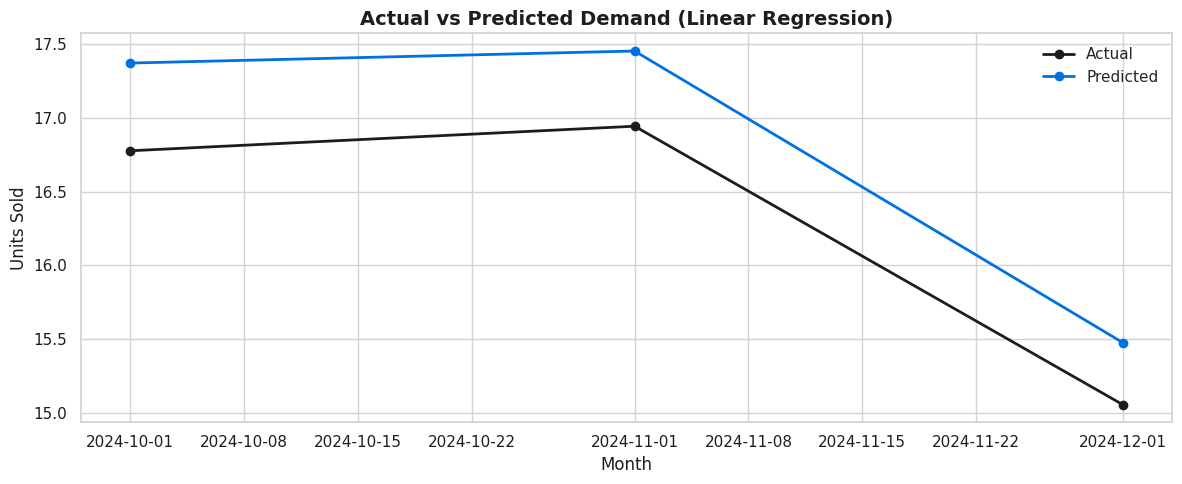

In [16]:
# ==========================================================
# STEP 15 - SELECT THE BEST MODEL
# ==========================================================

best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print("Best model selected:", best_model_name)
display(results_df[results_df["Model"] == best_model_name])

test_results = test_df[["month_start", "product_name"]].copy()
test_results["actual_units"] = y_test.values
test_results["predicted_units"] = best_predictions
test_results["predicted_units_rounded"] = test_results["predicted_units"].round(0)
test_results["error"] = test_results["actual_units"] - test_results["predicted_units"]
test_results["abs_error"] = np.abs(test_results["error"])

display(test_results.head(12))

# Monthly average comparison
plot_df = (
    test_results.groupby("month_start", as_index=False)[["actual_units", "predicted_units"]]
               .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(
    plot_df["month_start"],
    plot_df["actual_units"],
    marker="o",
    linewidth=2,
    color=APPLE_BLACK,
    label="Actual"
)

plt.plot(
    plot_df["month_start"],
    plot_df["predicted_units"],
    marker="o",
    linewidth=2,
    color=APPLE_BLUE,
    label="Predicted"
)

plt.title(f"Actual vs Predicted Demand ({best_model_name})", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

The selected model is the one that provides the most reliable balance across the evaluation metrics.

The goal is not to find a perfect forecast, is to find a model that is accurate enough to support better replenishment decisions than a simple rule of thumb.

## 16. FORECAST

A perfect forecast is not realistic in supply chain work. What matters is whether the model is strong enough to support better decisions than a simple guess or a fixed rule. In this project, the selected model creates a practical bridge between demand estimation and inventory planning.

After selecting the best model, we estimate next-month demand and converts those estimates into inventory indicators. In the final planning stage, the analysis reconnects the monthly model output with **category, product, and color**, so the recommendation becomes easier to use operationally.

In [17]:
# ==========================================================
# STEP 16 - FORECAST
# ==========================================================

monthly = monthly.copy()

color_cols = [col for col in monthly.columns if col.startswith("color_")]
monthly["color"] = monthly[color_cols].idxmax(axis=1).str.replace("color_", "", regex=False)

monthly = monthly.sort_values(["product_name", "color", "month_start"]).copy()
monthly["time_index"] = monthly.groupby(["product_name", "color"]).cumcount()

future_month = monthly["month_start"].max() + pd.offsets.MonthBegin(1)
future_rows = []

for (product, color), history in monthly.groupby(["product_name", "color"]):
    history = history.sort_values("month_start")
    last_row = history.iloc[-1]

    future_row = {
        "product_name": product,
        "color": color,
        "month_start": future_month,
        "time_index": history["time_index"].max() + 1,
        "lag_1_units": history["units_sold"].iloc[-1],
        "lag_2_units": history["units_sold"].iloc[-2] if len(history) >= 2 else history["units_sold"].iloc[-1],
        "lag_3_units": history["units_sold"].iloc[-3] if len(history) >= 3 else history["units_sold"].iloc[-1],
        "rolling_mean_3": history["units_sold"].tail(3).mean(),
        "avg_discount_pct": last_row["avg_discount_pct"],
        "avg_unit_price": last_row["avg_unit_price"],
        "transactions": last_row["transactions"],
    }

    for col in color_cols:
        future_row[col] = int(last_row[col])

    future_rows.append(future_row)

future_df = pd.DataFrame(future_rows)

for col in feature_cols:
    if col not in future_df.columns:
        future_df[col] = 0

X_future = future_df[feature_cols].copy()

if best_model_name == "Linear Regression":
    X_future = scaler.transform(X_future)

future_df["predicted_units_next_month"] = (
    np.ceil(best_model.predict(X_future))
    .clip(min=0)
    .astype(int)
)

display(
    future_df[
        ["product_name", "color", "month_start", "predicted_units_next_month"]
    ].head(18)
)

,product_name,color,month_start,predicted_units_next_month
0,AirPods (2nd Gen),Midnight,2025-01-01,480
1,AirPods (2nd Gen),Sky,2025-01-01,484
2,AirPods (2nd Gen),Starlight,2025-01-01,482
3,AirPods (2nd Gen),White,2025-01-01,489
4,AirPods Max,Midnight,2025-01-01,478
5,AirPods Max,Sky,2025-01-01,482
6,AirPods Max,Starlight,2025-01-01,485
7,AirPods Max,White,2025-01-01,485
8,AirPods Pro (2nd Gen),Midnight,2025-01-01,496
9,AirPods Pro (2nd Gen),Sky,2025-01-01,491


## 17. INVENTORY OPTIMIZATION

In [18]:
# ==========================================================
# STEP 17 - INVENTORY OPTIMIZATION CALCULATIONS
# ==========================================================

lead_time_map = {
    "Apple Watch": 0.8,
    "iPad": 1.0,
    "Mac": 1.2,
    "iPhone": 1.0,
    "AirPods": 0.7,
    "Accessories": 0.6
}

z_value = 1.65  # approximately 95% service level

std_last_6_map = (
    monthly.groupby(["product_name", "color"])["units_sold"]
           .apply(lambda s: s.tail(6).std(ddof=1))
           .fillna(0)
           .to_dict()
)

current_stock_proxy_map = (
    monthly.sort_values("month_start")
           .groupby(["product_name", "color"])["units_sold"]
           .last()
           .to_dict()
)

future_df["lead_time_months"] = future_df["product_name"].map(lead_time_map).fillna(1.0)

future_df["demand_std_last_6m"] = future_df.apply(
    lambda row: std_last_6_map.get((row["product_name"], row["color"]), 0),
    axis=1
)

future_df["current_stock_proxy"] = future_df.apply(
    lambda row: current_stock_proxy_map.get((row["product_name"], row["color"]), 0),
    axis=1
)

future_df["safety_stock"] = (
    z_value * future_df["demand_std_last_6m"] * np.sqrt(future_df["lead_time_months"])
)

future_df["reorder_point"] = (
    future_df["predicted_units_next_month"] * future_df["lead_time_months"] +
    future_df["safety_stock"]
)

future_df["target_stock_level"] = (
    future_df["predicted_units_next_month"] * (future_df["lead_time_months"] + 1) +
    future_df["safety_stock"]
)

future_df["recommended_order_qty"] = np.ceil(
    (future_df["target_stock_level"] - future_df["current_stock_proxy"]).clip(lower=0)
)

inventory_plan = future_df[
    [
        "product_name",
        "color",
        "month_start",
        "predicted_units_next_month",
        "lead_time_months",
        "demand_std_last_6m",
        "safety_stock",
        "reorder_point",
        "target_stock_level",
        "current_stock_proxy",
        "recommended_order_qty"
    ]
].copy()

inventory_plan = inventory_plan.rename(columns={"month_start": "forecast_month"})

cols_to_round = [
    "predicted_units_next_month",
    "lead_time_months",
    "demand_std_last_6m",
    "safety_stock",
    "reorder_point",
    "target_stock_level",
    "current_stock_proxy"
]

inventory_plan[cols_to_round] = inventory_plan[cols_to_round].round(2)

inventory_plan = inventory_plan.sort_values(
    ["product_name", "recommended_order_qty"],
    ascending=[True, False]
).reset_index(drop=True)

# ==========================================================
# ADD BUSINESS CLASS
# ==========================================================

conditions = [
    inventory_plan["recommended_order_qty"] >= inventory_plan["recommended_order_qty"].quantile(0.75),
    inventory_plan["recommended_order_qty"] >= inventory_plan["recommended_order_qty"].quantile(0.40),
]

choices = [
    "High Priority",
    "Medium Priority"
]

inventory_plan["business_class"] = np.select(
    conditions,
    choices,
    default="Low Priority"
)

display(inventory_plan)

,product_name,color,forecast_month,predicted_units_next_month,lead_time_months,demand_std_last_6m,safety_stock,reorder_point,target_stock_level,current_stock_proxy,recommended_order_qty,business_class
0,AirPods (2nd Gen),Sky,2025-01-01,484,1.000,7.120,11.740,495.740,979.740,11,969.000,Medium Priority
1,AirPods (2nd Gen),White,2025-01-01,489,1.000,4.230,6.980,495.980,984.980,16,969.000,Medium Priority
2,AirPods (2nd Gen),Starlight,2025-01-01,482,1.000,4.180,6.900,488.900,970.900,7,964.000,Low Priority
3,AirPods (2nd Gen),Midnight,2025-01-01,480,1.000,4.970,8.190,488.190,968.190,10,959.000,Low Priority
4,AirPods Max,White,2025-01-01,485,1.000,5.470,9.020,494.020,979.020,8,972.000,Medium Priority
...,...,...,...,...,...,...,...,...,...,...,...,...
110,iPhone 14 Pro,Black Titanium,2025-01-01,481,1.000,10.390,17.150,498.150,979.150,11,969.000,Medium Priority
111,iPhone 14 Pro,Midnight,2025-01-01,486,1.000,4.730,7.800,493.800,979.800,11,969.000,Medium Priority
112,iPhone 14 Pro,Green,2025-01-01,495,1.000,0.000,0.000,495.000,990.000,27,963.000,Low Priority
113,iPhone 14 Pro,Product Red,2025-01-01,492,1.000,1.410,2.330,494.330,986.330,26,961.000,Low Priority


# Interpretation

This graph presents a full inventory plan based on the historical data of the last 6 months fro the top 3 products of each cathegory. It includes the number of predicted units for next month, the lead time, safety stock, reorder points, target stock level and the recommended order quantity.

## 18. ABC ANALYSIS

In [19]:
# ==========================================================
# STEP 18 - ABC ANALYSIS BY PRODUCT AND COLOR
# ==========================================================

abc_df = (
    monthly.groupby(["product_name", "color"], as_index=False)
    .agg(
        total_units=("units_sold", "sum"),
        avg_price=("avg_unit_price", "mean")
    )
)

abc_df["annual_value"] = abc_df["total_units"] * abc_df["avg_price"]

abc_df = abc_df.sort_values("annual_value", ascending=False).reset_index(drop=True)

abc_df["cum_pct"] = abc_df["annual_value"].cumsum() / abc_df["annual_value"].sum()

abc_df["abc_class"] = np.where(
    abc_df["cum_pct"] <= 0.80,
    "A",
    np.where(abc_df["cum_pct"] <= 0.95, "B", "C")
)

abc_df["sku"] = abc_df["product_name"] + " - " + abc_df["color"]

display(
    abc_df[
        ["sku", "total_units", "avg_price", "annual_value", "cum_pct", "abc_class"]
    ]
)

# MERGE ABC CLASS INTO INVENTORY PLAN

inventory_plan = inventory_plan.merge(
    abc_df[["product_name", "color", "abc_class"]],
    on=["product_name", "color"],
    how="left"
)

,sku,total_units,avg_price,annual_value,cum_pct,abc_class
0,MacBook Pro 16-inch (M3 Pro) - Midnight,231,"2,498.144","577,071.257",0.089,A
1,MacBook Pro 16-inch (M3 Pro) - Gold,197,"2,494.996","491,514.209",0.165,A
2,MacBook Air 13-inch (M2) - Gold,197,"1,093.982","215,514.381",0.199,A
3,MacBook Pro 16-inch (M3 Pro) - Space Gray,85,"2,502.378","212,702.125",0.231,A
4,MacBook Air 13-inch (M2) - Silver,159,"1,100.936","175,048.866",0.258,A
...,...,...,...,...,...,...
110,Apple Watch SE (2nd Gen) - Starlight,26,255.306,"6,637.944",0.997,C
111,MagSafe Charger - Black,131,39.103,"5,122.523",0.998,C
112,MagSafe Charger - Silver,127,39.319,"4,993.469",0.999,C
113,MagSafe Charger - Space Gray,112,39.079,"4,376.834",1.000,C


#Interpretation

The ABC analysis is a Supply Chain Management tool that divides inventory in 3 classes based on the cost of volume in inventory where:

A: Highest cost (<60% of cumulated cost)

B: Medium cost

C: Lower cost (>80% of cumulated cost)

This It helps to establish policies that focus on the few critical parts and not on the most trivial ones, in this case, the top 3 products for each category.

## 19. REORDER POINTS

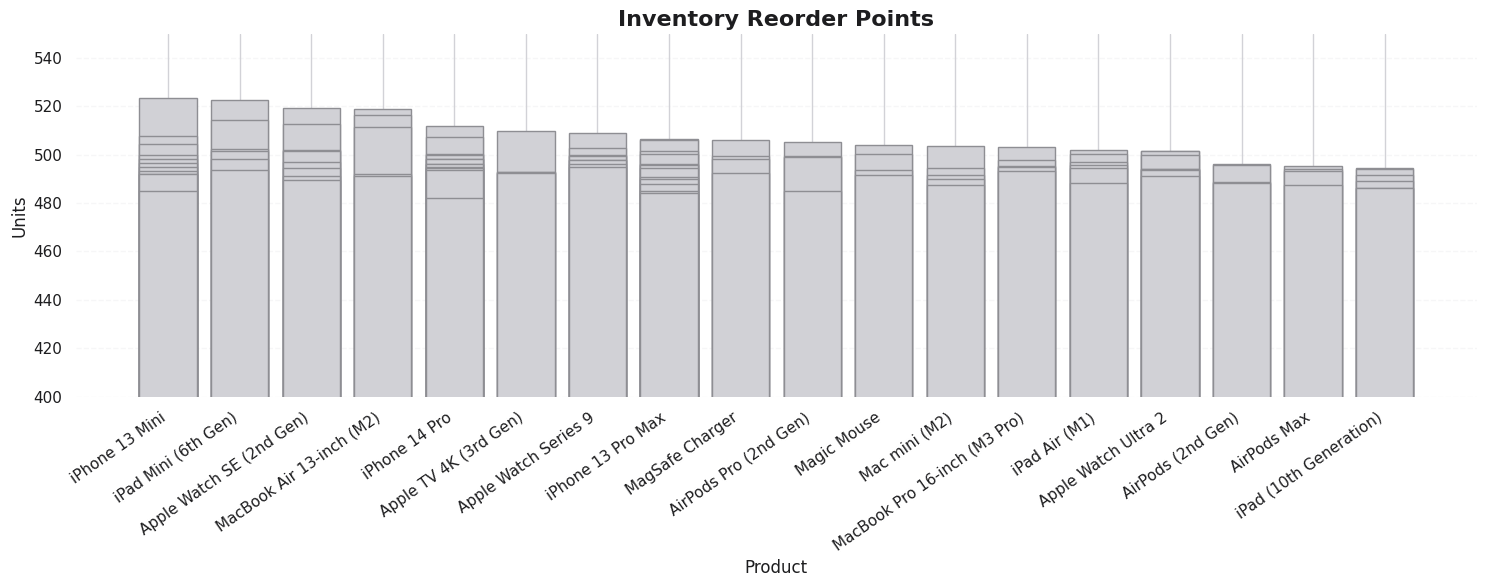

In [28]:
# ==========================================================
# STEP 19 - REORDER POINTS
# ==========================================================

plt.figure(figsize=(15, 6), facecolor="white")

inventory_sorted = inventory_plan.sort_values(
    "reorder_point",
    ascending=False
)

bars = plt.bar(
    inventory_sorted["product_name"],
    inventory_sorted["reorder_point"],
    color="#D1D1D6",
    edgecolor="#8E8E93"
)

plt.title(
    "Inventory Reorder Points",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product")
plt.ylabel("Units")

plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.2)

plt.box(False)
plt.ylim(ymin=400)
plt.tight_layout()
plt.show()

#Interpretation

It is necessary to know the exact dates of reordering products according to the date when the stock reaches the marked level. This is to avoid both stockouts and overstock. We decided to perform the reorder point analysis in the predicted demand, but basing on the historical demand.

## 20. SAFETY STOCK LEVELS

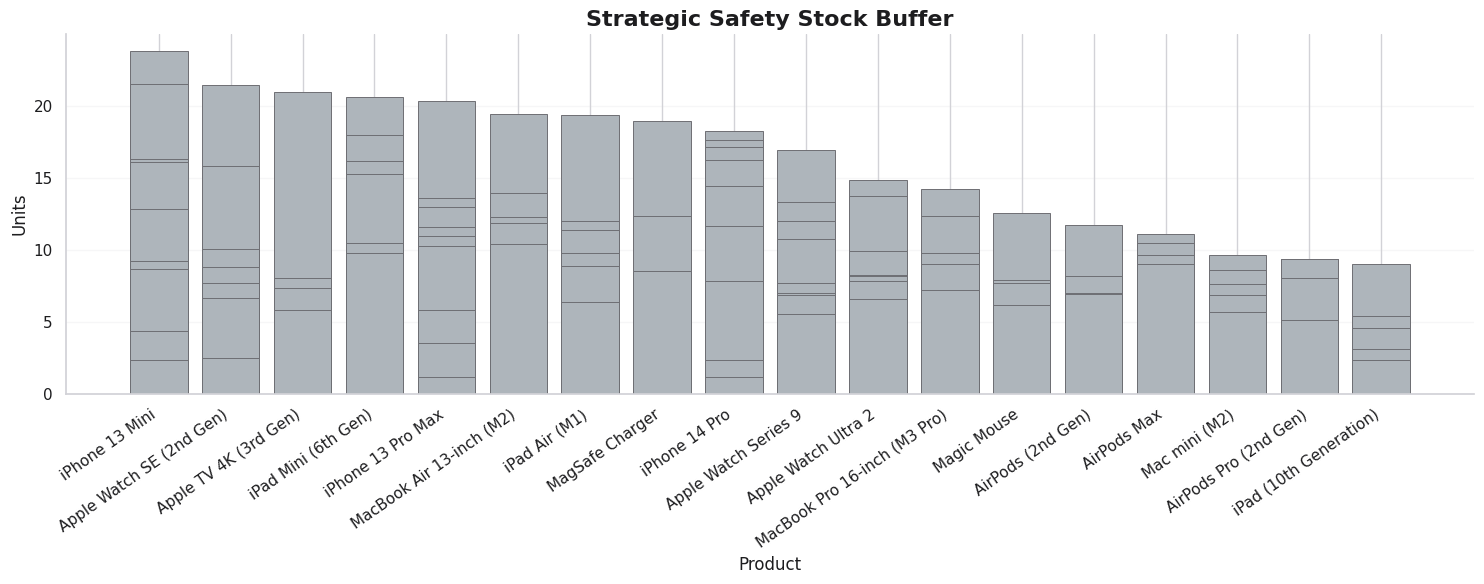

In [21]:
# ==========================================================
# STEP 20 - SAFETY STOCK LEVELS
# ==========================================================

plt.figure(figsize=(15, 6), facecolor="white")

safety_sorted = inventory_plan.sort_values(
    "safety_stock",
    ascending=False
)

plt.bar(
    safety_sorted["product_name"],
    safety_sorted["safety_stock"],
    color="#AEB5BB",
    edgecolor="#6E6E73",
    linewidth=0.7
)

plt.title(
    "Strategic Safety Stock Buffer",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product")
plt.ylabel("Units")

plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.18)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D2D2D7")
ax.spines["bottom"].set_color("#D2D2D7")

plt.tight_layout()
plt.show()

#Interpretation

Safety stock buffer is what makes the reorder point realistic instead of risky. It helps to be aware of how many products are in stock in order to protect against uncertainty.
Since Apple launches new products every year, the stock buffer is every time lower for the products that are moving everytime more aside in order for the new products to enter, which is why the olderst generations of products are the lowest.

## 21. EXECUTIVE INVENTORY PLAN

In [22]:
inventory_plan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   product_name                115 non-null    object        
 1   color                       115 non-null    object        
 2   forecast_month              115 non-null    datetime64[ns]
 3   predicted_units_next_month  115 non-null    int64         
 4   lead_time_months            115 non-null    float64       
 5   demand_std_last_6m          115 non-null    float64       
 6   safety_stock                115 non-null    float64       
 7   reorder_point               115 non-null    float64       
 8   target_stock_level          115 non-null    float64       
 9   current_stock_proxy         115 non-null    int64         
 10  recommended_order_qty       115 non-null    float64       
 11  business_class              115 non-null    object        

In [23]:
## ==========================================================
# STEP 21 - EXECUTIVE INVENTORY PLAN
# ==========================================================

executive_inventory_plan = inventory_plan[
    [
        "product_name",
        "color",
        "forecast_month",
        "predicted_units_next_month",
        "abc_class",
        "business_class",
        "safety_stock",
        "reorder_point",
        "target_stock_level",
        "recommended_order_qty"
    ]
].copy()

executive_inventory_plan = executive_inventory_plan.rename(
    columns={
        "product_name": "Product",
        "color": "Color",
        "forecast_month": "Forecast Month",
        "predicted_units_next_month": "Forecast Demand",
        "abc_class": "ABC Class",
        "business_class": "Business Class",
        "reorder_point": "Reorder Point",
        "safety_stock": "Safety Stock",
        "target_stock_level": "Target Stock Level",
        "recommended_order_qty": "Recommended Order Qty"
    }
)

numeric_cols = [
    "Forecast Demand",
    "Safety Stock",
    "Reorder Point",
    "Target Stock Level",
    "Recommended Order Qty"
]

executive_inventory_plan[numeric_cols] = (
    executive_inventory_plan[numeric_cols]
    .round(0)
    .astype(int)
)

executive_inventory_plan = executive_inventory_plan.sort_values(
    ["Product", "Recommended Order Qty"],
    ascending=[True, False]
).reset_index(drop=True)

display(executive_inventory_plan)

,Product,Color,Forecast Month,Forecast Demand,ABC Class,Business Class,Safety Stock,Reorder Point,Target Stock Level,Recommended Order Qty
0,AirPods (2nd Gen),Sky,2025-01-01,484,C,Medium Priority,12,496,980,969
1,AirPods (2nd Gen),White,2025-01-01,489,B,Medium Priority,7,496,985,969
2,AirPods (2nd Gen),Starlight,2025-01-01,482,C,Low Priority,7,489,971,964
3,AirPods (2nd Gen),Midnight,2025-01-01,480,B,Low Priority,8,488,968,959
4,AirPods Max,White,2025-01-01,485,B,Medium Priority,9,494,979,972
...,...,...,...,...,...,...,...,...,...,...
110,iPhone 14 Pro,Black Titanium,2025-01-01,481,A,Medium Priority,17,498,979,969
111,iPhone 14 Pro,Midnight,2025-01-01,486,A,Medium Priority,8,494,980,969
112,iPhone 14 Pro,Green,2025-01-01,495,B,Low Priority,0,495,990,963
113,iPhone 14 Pro,Product Red,2025-01-01,492,A,Low Priority,2,494,986,961


#Interpretation

This table shows a summary of the ABC analysis, the reorder points and the safety stock, as well as many other important information for a supply chain manager to understand what happens with the products and be aware of the next steps

## 22. APPLE INVENTORY OPTIMIZATION DASHBOARD
Rather than adding more technical detail, it highlights the main decisions: where forecast demand is concentrated, which categories require the largest replenishment effort, which product-color combinations deserve closer attention, and how the selected model performed.


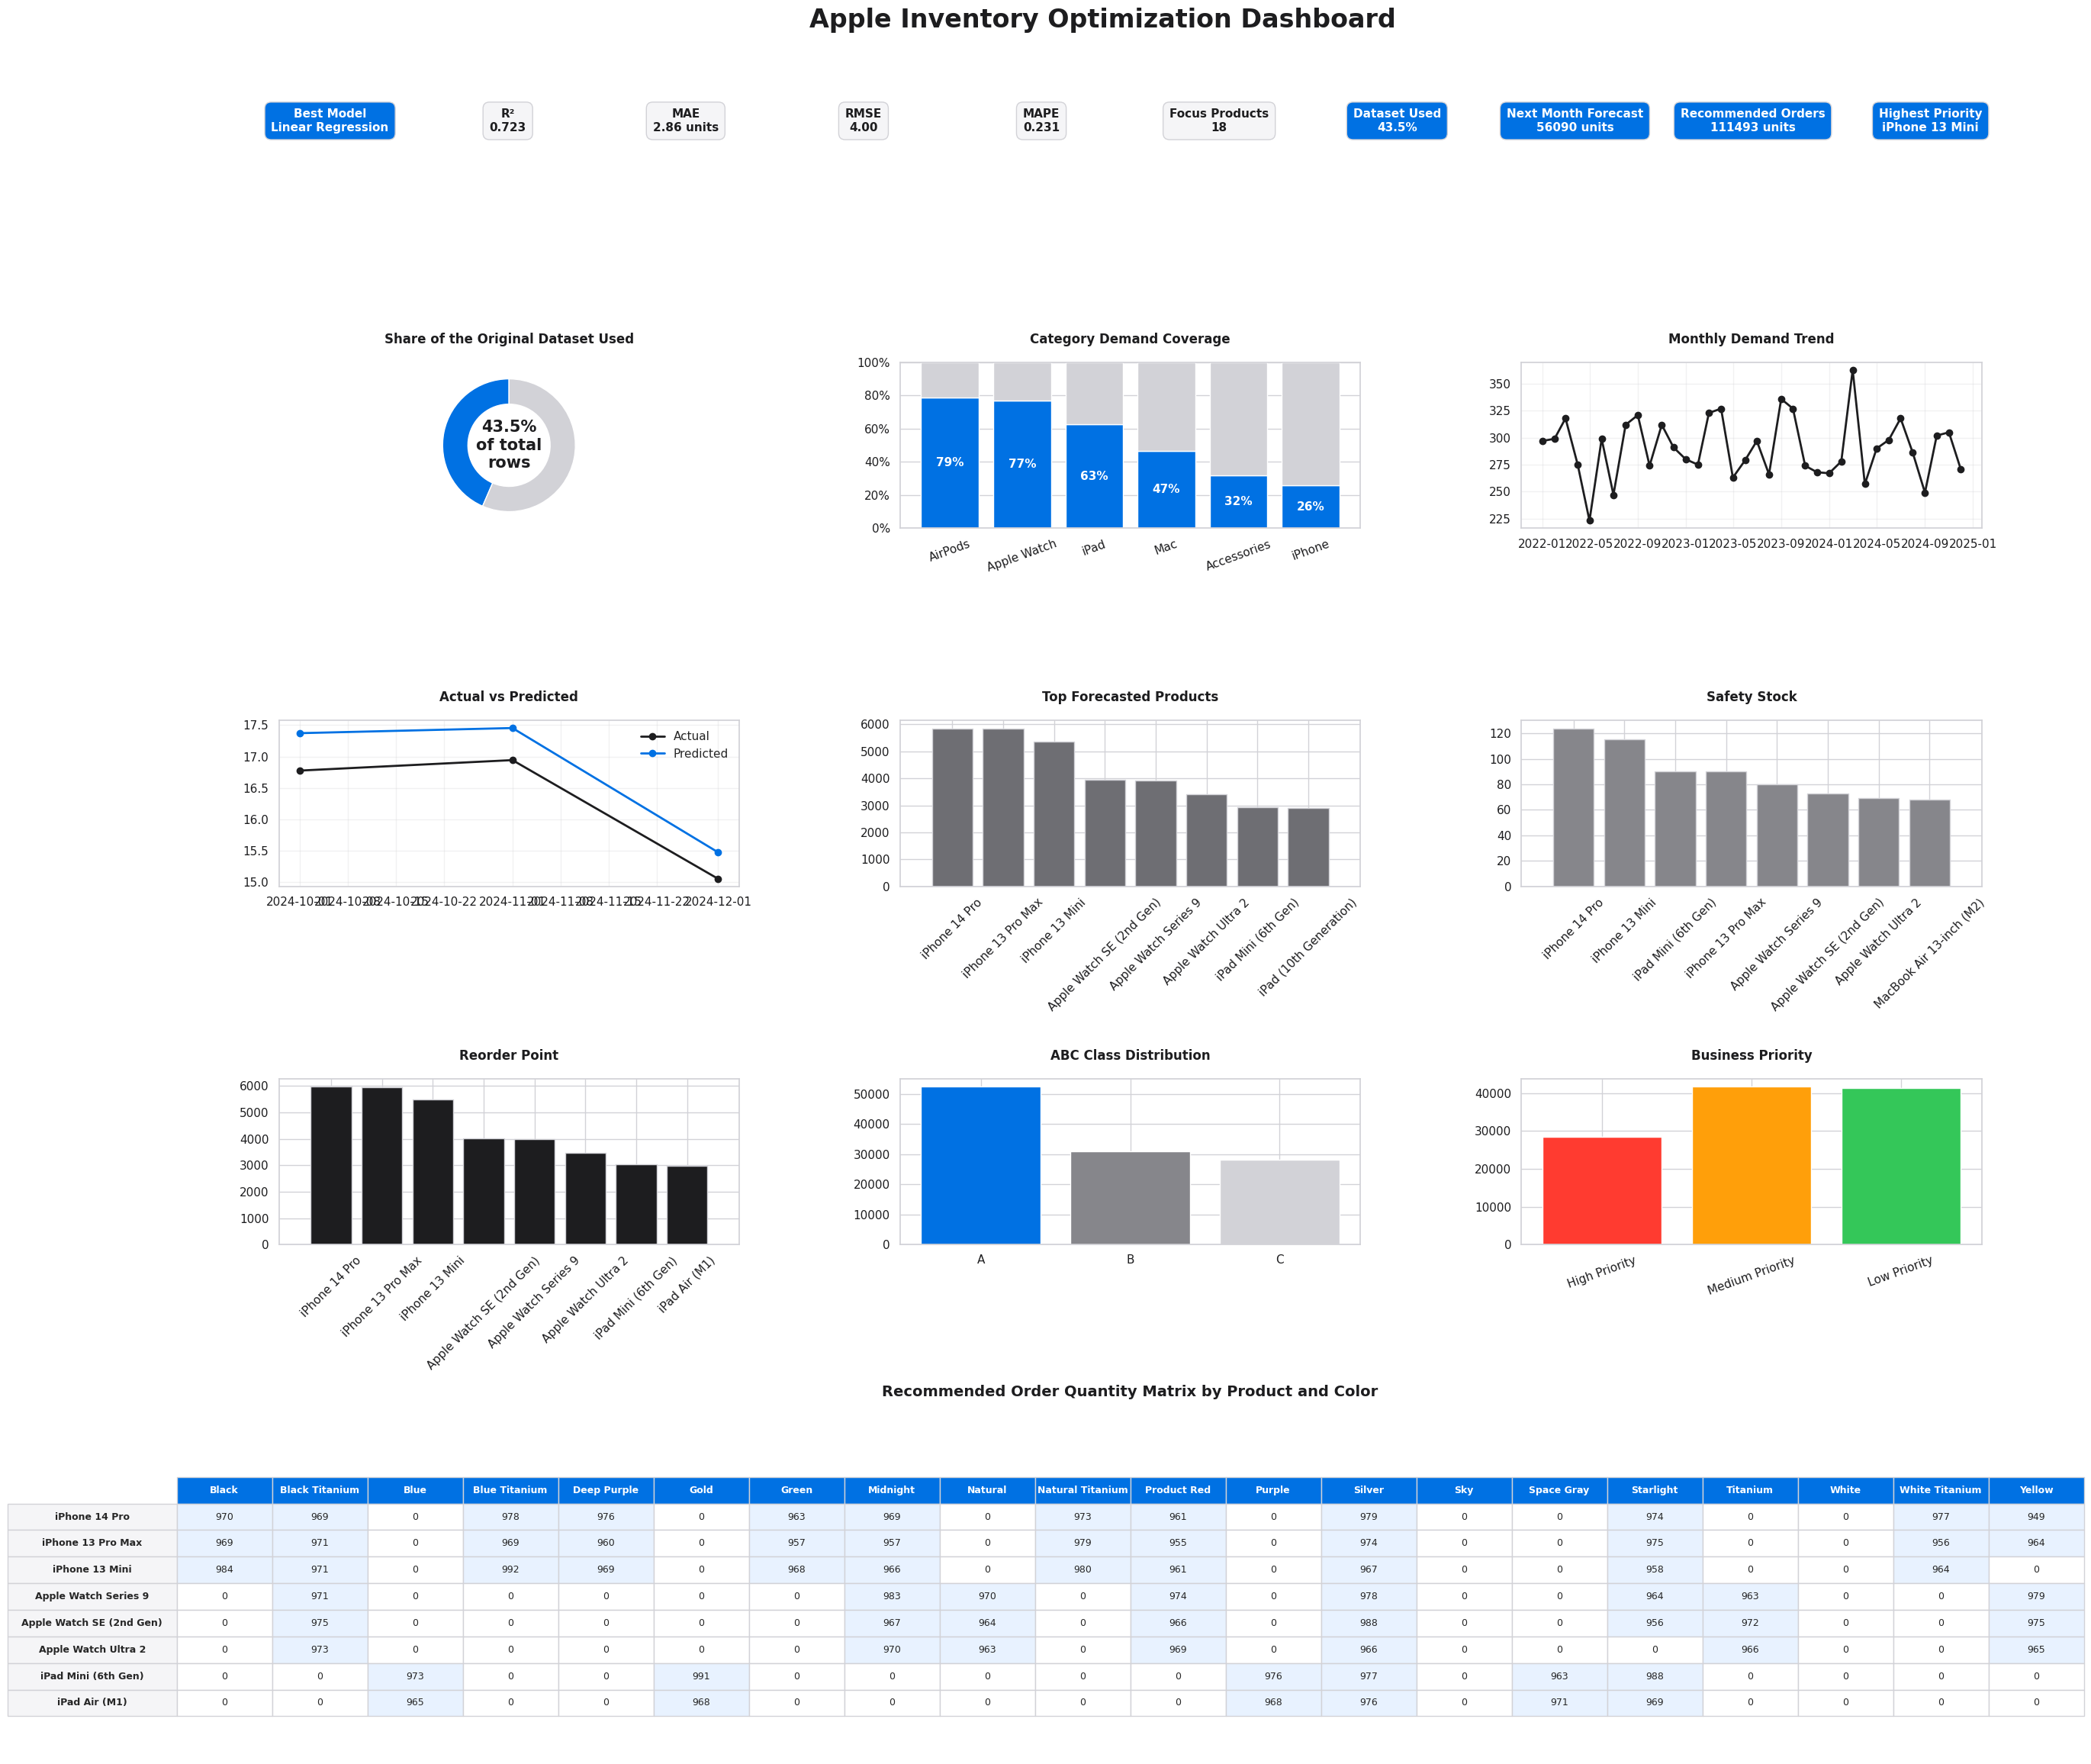

In [24]:
# ==========================================================
# STEP 22 - APPLE EXECUTIVE DASHBOARD
# ==========================================================
from matplotlib.ticker import PercentFormatter

APPLE_BLACK = "#1D1D1F"
APPLE_BLUE = "#0071E3"
APPLE_SILVER = "#D2D2D7"
APPLE_LIGHT = "#F5F5F7"
APPLE_GRAY = "#86868B"
APPLE_DARK_GRAY = "#6E6E73"
APPLE_GREEN = "#34C759"
APPLE_ORANGE = "#FF9F0A"
APPLE_RED = "#FF3B30"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = APPLE_SILVER
plt.rcParams["axes.labelcolor"] = APPLE_BLACK
plt.rcParams["axes.titlecolor"] = APPLE_BLACK
plt.rcParams["xtick.color"] = APPLE_BLACK
plt.rcParams["ytick.color"] = APPLE_BLACK
plt.rcParams["grid.color"] = APPLE_SILVER
plt.rcParams["font.size"] = 11

# ----------------------------------------------------------
# KPI METRICS
# ----------------------------------------------------------
best_row = results_df.sort_values("RMSE").iloc[0]

best_model_name = best_row["Model"]
best_r2 = best_row["R2"]
best_mae = best_row["MAE"]
best_rmse = best_row["RMSE"]

if "sMAPE" in results_df.columns:
    best_error_pct = best_row["sMAPE"]
    metric_label = "sMAPE"
elif "MAPE" in results_df.columns:
    best_error_pct = best_row["MAPE"]
    metric_label = "MAPE"
else:
    best_error_pct = np.nan
    metric_label = "Error %"

total_forecast = future_df["predicted_units_next_month"].sum()
total_safety_stock = future_df["safety_stock"].sum()
total_recommended_order = inventory_plan["recommended_order_qty"].sum()

highest_priority_product = (
    inventory_plan.sort_values("recommended_order_qty", ascending=False)
    .iloc[0]["product_name"]
)

focused_products_n = inventory_plan["product_name"].nunique()

# ----------------------------------------------------------
# SEGMENTATION COVERAGE - DATASET USAGE
# ----------------------------------------------------------
rows_total = len(df)
rows_segmented = len(top_df)
rows_not_used = rows_total - rows_segmented

coverage_pct = rows_segmented / rows_total
not_used_pct = rows_not_used / rows_total

# ----------------------------------------------------------
# CATEGORY COVERAGE - TOP 3 SHARE
# ----------------------------------------------------------
category_total = (
    df.groupby("category", as_index=False)["units_sold"]
    .sum()
    .rename(columns={"units_sold": "total_units_category"})
)

category_segmented = (
    top_df.groupby("category", as_index=False)["units_sold"]
    .sum()
    .rename(columns={"units_sold": "units_top3"})
)

category_coverage = category_total.merge(category_segmented, on="category", how="left")
category_coverage["units_top3"] = category_coverage["units_top3"].fillna(0)

category_coverage["pct_top3"] = (
    category_coverage["units_top3"] / category_coverage["total_units_category"]
)
category_coverage["pct_rest"] = 1 - category_coverage["pct_top3"]

category_coverage = category_coverage.sort_values("pct_top3", ascending=False)

# ----------------------------------------------------------
# PREPARE DATA FOR VISUALS
# ----------------------------------------------------------
monthly_total = (
    monthly.groupby("month_start", as_index=False)["units_sold"]
    .sum()
)

forecast_per_month = (
    test_results.groupby("month_start", as_index=False)[["actual_units", "predicted_units"]]
    .mean()
)

top_forecast = (
    future_df.groupby("product_name", as_index=False)["predicted_units_next_month"]
    .sum()
    .sort_values("predicted_units_next_month", ascending=False)
    .head(8)
)

top_safety = (
    inventory_plan.groupby("product_name", as_index=False)["safety_stock"]
    .sum()
    .sort_values("safety_stock", ascending=False)
    .head(8)
)

top_reorder = (
    inventory_plan.groupby("product_name", as_index=False)["reorder_point"]
    .sum()
    .sort_values("reorder_point", ascending=False)
    .head(8)
)

abc_distribution = (
    inventory_plan.groupby("abc_class", as_index=False)
    .agg(
        sku_count=("product_name", "count"),
        total_order_qty=("recommended_order_qty", "sum")
    )
    .sort_values("abc_class")
)

business_distribution = (
    inventory_plan.groupby("business_class", as_index=False)
    .agg(
        sku_count=("product_name", "count"),
        total_order_qty=("recommended_order_qty", "sum")
    )
)

business_order = ["High Priority", "Medium Priority", "Low Priority"]
business_distribution["business_class"] = pd.Categorical(
    business_distribution["business_class"],
    categories=business_order,
    ordered=True
)
business_distribution = business_distribution.sort_values("business_class")

# ----------------------------------------------------------
# FIGURE LAYOUT
# ----------------------------------------------------------

fig = plt.figure(figsize=(24, 24))
gs = gridspec.GridSpec(
    5, 3,
    figure=fig,
    height_ratios=[0.8, 1.35, 1.35, 1.35, 2.6],
    hspace=1.05,
    wspace=0.35
)

fig.suptitle(
    "Apple Inventory Optimization Dashboard",
    fontsize=24,
    fontweight="bold",
    color=APPLE_BLACK,
    y=0.985
)

# ----------------------------------------------------------
# KPI PANEL
# ----------------------------------------------------------
ax0 = fig.add_subplot(gs[0, :])
ax0.axis("off")

kpi_boxes = [
    f"Best Model\n{best_model_name}",
    f"R²\n{best_r2:.3f}",
    f"MAE\n{best_mae:.2f} units",
    f"RMSE\n{best_rmse:.2f}",
    f"{metric_label}\n{best_error_pct:.3f}",
    f"Focus Products\n{focused_products_n}",
    f"Dataset Used\n{coverage_pct:.1%}",
    f"Next Month Forecast\n{total_forecast:.0f} units",
    f"Recommended Orders\n{total_recommended_order:.0f} units",
    f"Highest Priority\n{highest_priority_product}",
]

x_positions = np.linspace(0.03, 0.97, len(kpi_boxes))

for i, (x, text) in enumerate(zip(x_positions, kpi_boxes)):
    color = APPLE_BLUE if i in [0, 6, 7, 8, 9] else APPLE_LIGHT
    text_color = "white" if color == APPLE_BLUE else APPLE_BLACK

    ax0.text(
        x, 0.5, text,
        ha="center", va="center",
        fontsize=11,
        fontweight="bold",
        color=text_color,
        bbox=dict(
            facecolor=color,
            edgecolor=APPLE_SILVER,
            boxstyle="round,pad=0.55"
        )
    )

# ----------------------------------------------------------
# CHART 1 - DONUT
# ----------------------------------------------------------
ax1 = fig.add_subplot(gs[1, 0])

sizes = [rows_segmented, rows_not_used]
colors = [APPLE_BLUE, APPLE_SILVER]

wedges, _ = ax1.pie(
    sizes,
    labels=None,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.38, edgecolor="white")
)

ax1.text(
    0, 0,
    f"{coverage_pct:.1%}\nof total\nrows",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
    color=APPLE_BLACK
)

ax1.set_title("Share of the Original Dataset Used", fontweight="bold", pad=18)

# ----------------------------------------------------------
# CHART 2 - CATEGORY COVERAGE
# ----------------------------------------------------------
ax2 = fig.add_subplot(gs[1, 1])

ax2.bar(
    category_coverage["category"],
    category_coverage["pct_top3"],
    color=APPLE_BLUE,
    edgecolor="white"
)

ax2.bar(
    category_coverage["category"],
    category_coverage["pct_rest"],
    bottom=category_coverage["pct_top3"],
    color=APPLE_SILVER,
    edgecolor="white"
)

for i, v in enumerate(category_coverage["pct_top3"]):
    ax2.text(
        i,
        v / 2,
        f"{v:.0%}",
        ha="center",
        va="center",
        color="white" if v > 0.18 else APPLE_BLACK,
        fontweight="bold"
    )

ax2.set_title("Category Demand Coverage", fontweight="bold", pad=18)
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.tick_params(axis="x", rotation=20)

# ----------------------------------------------------------
# CHART 3 - DEMAND TREND
# ----------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 2])

ax3.plot(
    monthly_total["month_start"],
    monthly_total["units_sold"],
    color=APPLE_BLACK,
    marker="o",
    linewidth=2
)

ax3.set_title("Monthly Demand Trend", fontweight="bold", pad=18)
ax3.grid(True, alpha=0.3)

# ----------------------------------------------------------
# CHART 4 - ACTUAL VS PREDICTED
# ----------------------------------------------------------
ax4 = fig.add_subplot(gs[2, 0])

ax4.plot(
    forecast_per_month["month_start"],
    forecast_per_month["actual_units"],
    color=APPLE_BLACK,
    marker="o",
    linewidth=2,
    label="Actual"
)

ax4.plot(
    forecast_per_month["month_start"],
    forecast_per_month["predicted_units"],
    color=APPLE_BLUE,
    marker="o",
    linewidth=2,
    label="Predicted"
)

ax4.set_title("Actual vs Predicted", fontweight="bold", pad=18)
ax4.legend(frameon=False)
ax4.grid(True, alpha=0.3)

# ----------------------------------------------------------
# CHART 5 - FORECASTED PRODUCTS
# ----------------------------------------------------------
ax5 = fig.add_subplot(gs[2, 1])

ax5.bar(
    top_forecast["product_name"],
    top_forecast["predicted_units_next_month"],
    color=APPLE_DARK_GRAY,
    edgecolor=APPLE_SILVER
)

ax5.set_title("Top Forecasted Products", fontweight="bold", pad=18)
ax5.tick_params(axis="x", rotation=45)
ax5.margins(x=0.08)

# ----------------------------------------------------------
# CHART 6 - SAFETY STOCK
# ----------------------------------------------------------
ax6 = fig.add_subplot(gs[2, 2])

ax6.bar(
    top_safety["product_name"],
    top_safety["safety_stock"],
    color=APPLE_GRAY,
    edgecolor=APPLE_SILVER
)

ax6.set_title("Safety Stock", fontweight="bold", pad=18)
ax6.tick_params(axis="x", rotation=45)
ax6.margins(x=0.08)

# ----------------------------------------------------------
# CHART 7 - REORDER POINT
# ----------------------------------------------------------
ax7 = fig.add_subplot(gs[3, 0])

ax7.bar(
    top_reorder["product_name"],
    top_reorder["reorder_point"],
    color=APPLE_BLACK,
    edgecolor=APPLE_SILVER
)

ax7.set_title("Reorder Point", fontweight="bold", pad=18)
ax7.tick_params(axis="x", rotation=45)
ax7.margins(x=0.08)

# ----------------------------------------------------------
# CHART 8 - ABC
# ----------------------------------------------------------
ax8 = fig.add_subplot(gs[3, 1])

ax8.bar(
    abc_distribution["abc_class"],
    abc_distribution["total_order_qty"],
    color=[APPLE_BLUE, APPLE_GRAY, APPLE_SILVER]
)

ax8.set_title("ABC Class Distribution", fontweight="bold", pad=18)

# ----------------------------------------------------------
# CHART 9 - BUSINESS
# ----------------------------------------------------------
ax9 = fig.add_subplot(gs[3, 2])

business_colors = {
    "High Priority": APPLE_RED,
    "Medium Priority": APPLE_ORANGE,
    "Low Priority": APPLE_GREEN
}

ax9.bar(
    business_distribution["business_class"],
    business_distribution["total_order_qty"],
    color=[business_colors[x] for x in business_distribution["business_class"]]
)

ax9.set_title("Business Priority", fontweight="bold", pad=18)
ax9.tick_params(axis="x", rotation=20)

# ----------------------------------------------------------
# CHART 10 - MATRIX
# ----------------------------------------------------------
ax10 = fig.add_subplot(gs[4, :])
ax10.axis("off")

recommended_matrix = (
    inventory_plan.groupby(["product_name", "color"], as_index=False)["recommended_order_qty"]
    .sum()
    .pivot(index="product_name", columns="color", values="recommended_order_qty")
    .fillna(0)
    .round(0)
    .astype(int)
)

recommended_matrix = recommended_matrix.loc[
    recommended_matrix.sum(axis=1).sort_values(ascending=False).index[:8]
]

table = ax10.table(
    cellText=recommended_matrix.values,
    rowLabels=recommended_matrix.index,
    colLabels=recommended_matrix.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.12, 1.75)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor(APPLE_SILVER)

    if row == 0:
        cell.set_facecolor(APPLE_BLUE)
        cell.set_text_props(color="white", weight="bold")
    elif col == -1:
        cell.set_facecolor(APPLE_LIGHT)
        cell.set_text_props(weight="bold")
    else:
        value = recommended_matrix.iloc[row - 1, col]
        cell.set_facecolor("#E8F2FF" if value > 0 else "white")

ax10.set_title(
    "Recommended Order Quantity Matrix by Product and Color",
    fontsize=14,
    fontweight="bold",
    pad=38
)

plt.subplots_adjust(
    top=0.95,
    bottom=0.03,
    left=0.05,
    right=0.98,
    hspace=1.05,
    wspace=0.35
)

plt.show()

## 23. FINAL CONCLUSION



It is undeniable that for Apple, as for any company, demand is volatile, especially for an innovative and well-established one. In this project, we presented a comprehensive supply chain analysis, relying not only on the analysis of historical sales data and the construction of predictive models, but also on a rigorous framework. This allowed us to estimate future demand trends for flagship products and evaluate the model's performance using error metrics such as mean absolute error (MAE) and root mean square error (RMSE). To do this, we selected the three best-performing products in each category offered by Apple, focusing on the most important products for the coming year, which enabled a more strategic and business-oriented analysis.

It is important to note that Apple launches new products in almost all of its categories every year. Therefore, even if demand appears stable throughout the year, it experiences significant fluctuations at certain times. This is why supply chain managers need to closely monitor their inventory levels.

This study demonstrates how predictive analytics can significantly improve inventory management by shifting from reactive to data-driven decision-making. The results showed that demand varies not only over time but also from product to product, highlighting the importance of segmenting inventory decisions rather than applying a one-size-fits-all approach.

Furthermore, by incorporating forecast errors into safety stock calculations, the study introduced a dynamic margin that adapts to uncertainty. This approach improves service levels while reducing the risk of overstocking, thus providing a more efficient balance between availability and cost.

Overall, integrating demand forecasting, product-level analytics, and inventory optimization concepts (such as reorder point and safety stock) provides a scalable framework for improving supply chain performance.

Future improvements could include the use of more advanced forecasting models, the integration of external variables (such as promotions or seasonal factors) and the simulation of inventory management policies to further optimize ordering strategies.